# Pipeline de Datos: Análisis Exploratorio de Inversión Educativa (AMBA)

---

In [201]:
import numpy as np
import pandas as pd
import seaborn.objects as so
from formulaic import Formula
from sklearn import linear_model  
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

Importacion y Origenes de Datos
--
Los datasets analizados son el resultado de un proceso de ETL (Extract, Transform, Load) previo, ejecutado mediante consultas SQL.

**Metodología de Extracción** La creación de la base de datos y las queries de creación de estos conjuntos de datos, se encuentran documentadas en un cuaderno técnico complementario.

In [202]:
df_alumnos_colegio=pd.read_csv(r"G:\Mi unidad\Proyecto Repitencia\Datasets_jupyter\jup_alumnos_colegios.csv")
df_alumnos_colegio.head()

,anio,zona,unidades_de_servicio_nivel_inicial,unidades_de_servicio_nivel_primario,unidades_de_servicio_nivel_secundario,sector_de_gestion_estatal,sector_de_gestion_privada,matricula_nivel_inicial,matricula_nivel_primario,matricula_nivel_secundario,matricula_sexo_masculino,matricula_sexo_femenino,matricula_total
0,2013,interior,859,866,747,2356,1117,130339,316391,226264,430394,446912,672994
1,2013,norte,659,595,589,1271,1178,99429,218510,179965,296709,304661,497904
2,2013,oeste,413,431,436,1116,675,72559,187415,142718,242813,254588,402692
3,2013,sur,975,961,997,2576,1486,166198,421984,331583,558089,569857,919765
4,2013,suroeste,291,327,332,842,444,51402,156664,126988,196101,200739,335054


In [203]:
df_poblacion_inversion=pd.read_csv(r"G:\Mi unidad\Proyecto Repitencia\Datasets_jupyter\jup_poblacion_inversion.csv")
df_poblacion_inversion.head()
df_poblacion_inversion[df_poblacion_inversion["anio"]==2022]

,anio,zona,poblacion_total,inversion_alumno,inversion_educativa_usd
45,2022,interior,3201056,58.37,44846923
46,2022,norte,2328154,48.08,24117331
47,2022,oeste,1856174,55.98,23849939
48,2022,sur,4132655,55.66,53708696
49,2022,suroeste,1841247,61.73,22278900


In [204]:
df_repitencia=pd.read_csv(r"G:\Mi unidad\Proyecto Repitencia\Datasets_jupyter\jup_repitencia.csv")
df_repitencia.head()

,anio,zona,promocion_efectiva_primaria,promocion_efectiva_secundaria,repitencia_primaria,repitencia_secundaria,reinscripcion_primaria,reinscripcion_secundaria,abandono_interanual_primaria,abandono_interanual_secundaria,...,alumnos_no_promovidos_primaria,alumnos_no_promovidos_secundaria,salidos_sin_pase_primaria,salidos_sin_pase_secundaria,salidos_con_pase_primaria,salidos_con_pase_secundaria,sobreedad_primaria,sobreedad_secundaria,sobreedad_avanzada_primaria,sobreedad_avanzada_secundaria
0,2013,interior,98.28,80.22,1.63,10.63,0.18,1.79,-0.09,7.36,...,1.34,19.28,0.30,1.66,4.07,4.36,11.71,35.32,3.22,14.69
1,2013,norte,98.02,84.14,1.28,8.41,0.10,1.51,0.60,5.94,...,1.19,20.16,0.30,0.85,3.02,3.64,9.56,32.51,2.30,13.41
2,2013,oeste,97.79,82.43,1.58,10.21,0.15,1.80,0.48,5.56,...,1.55,20.87,0.28,2.06,3.23,4.09,9.39,34.65,2.48,14.86
3,2013,sur,97.51,79.92,1.74,10.97,0.13,1.71,0.62,7.40,...,1.72,22.45,0.32,1.78,3.63,3.78,11.88,36.41,3.40,15.90
4,2013,suroeste,97.53,81.91,1.59,9.17,0.10,1.44,0.78,7.47,...,1.52,20.84,0.47,1.19,2.98,3.63,11.51,37.00,3.04,15.72


**Analisis Exploratorio: Área Metropolitana(2022)** 
--

In [205]:
#Separo mis datasets en el año correspondiente a mi analisis exploratorio.
df_2022_alumnos_colegio=df_alumnos_colegio[df_alumnos_colegio["anio"]==2022].copy()
df_2022_repitencia=df_repitencia[df_repitencia["anio"]==2022].copy()
df_2022_poblacion_inversion=df_poblacion_inversion[df_poblacion_inversion["anio"]==2022].copy()

Analisis general por zona
--

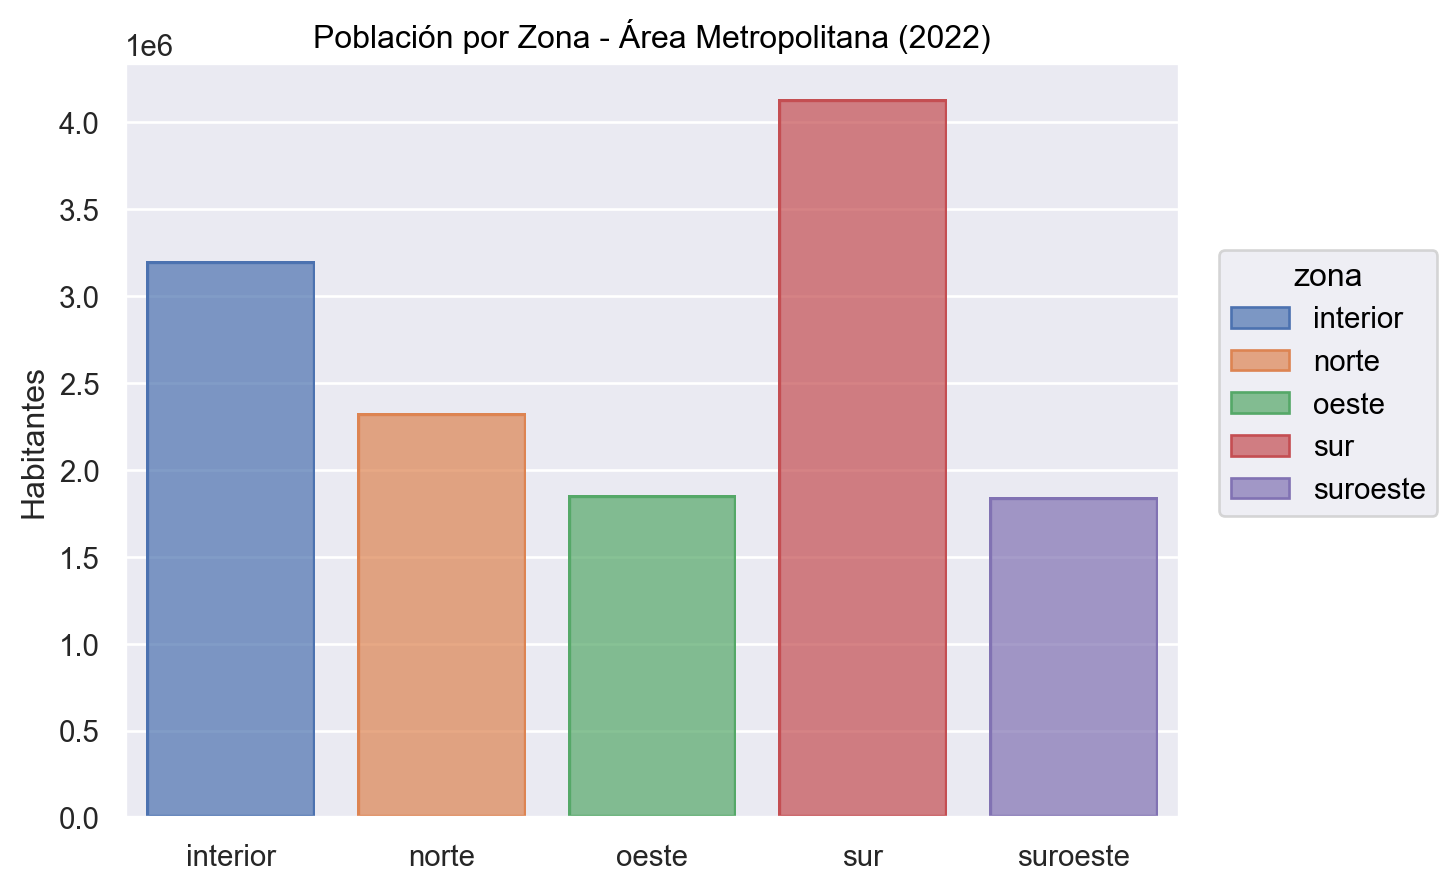

In [206]:
(so.Plot(df_2022_poblacion_inversion,x="zona",y="poblacion_total",color="zona")
    .add(so.Bar())
    .label(title="Población por Zona - Área Metropolitana (2022)",x="",y="Habitantes"))

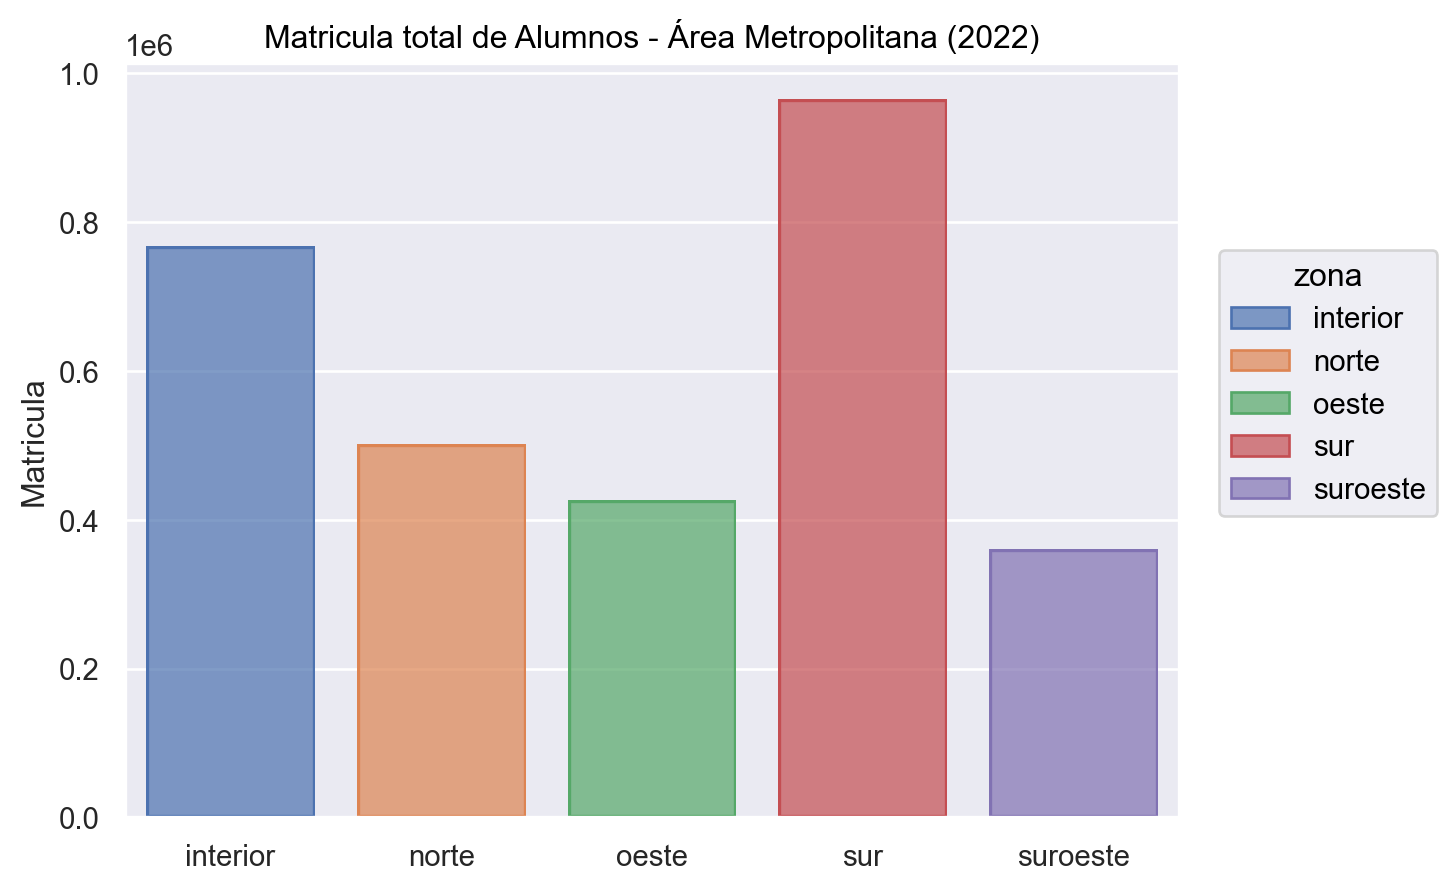

In [207]:
(so.Plot(df_2022_alumnos_colegio,x="zona",y="matricula_total",color="zona")
 .add(so.Bar())
 .label(title="Matricula total de Alumnos - Área Metropolitana (2022)",y="Matricula",x=None))

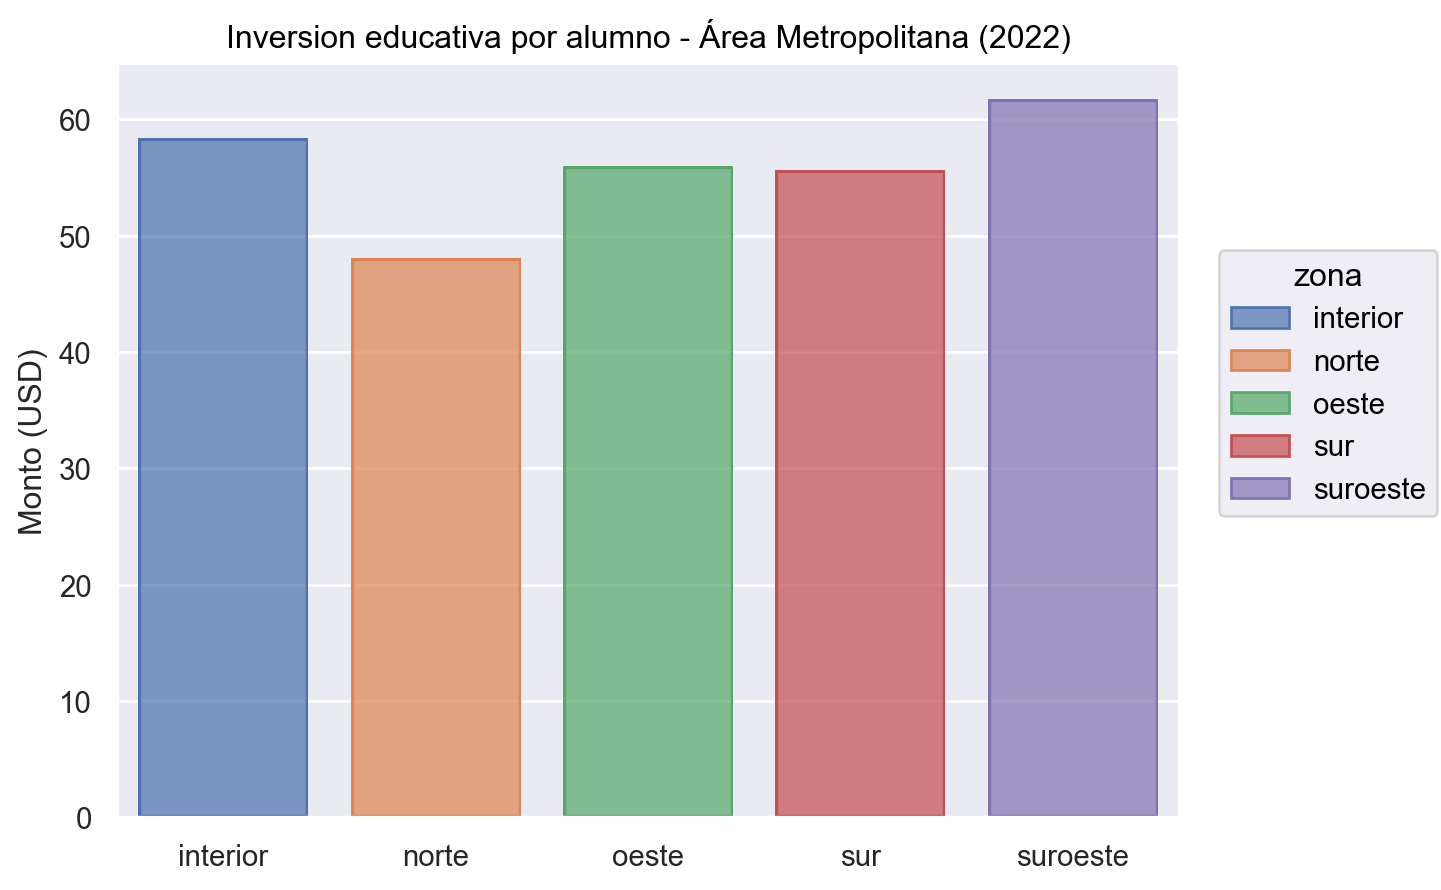

In [208]:
(so.Plot(df_2022_poblacion_inversion,x="zona",y="inversion_alumno",color="zona")
 .add(so.Bar())
 .label(title="Inversion educativa por alumno - Área Metropolitana (2022)",y="Monto (USD)",x=None))

In [209]:
#Armo una nueva tabla en donde su uso va a ser separar la cantidad de colegios respecto a su tipo de gestion, utilizando herramientas de pandas.
grafico_gestion=df_2022_alumnos_colegio.copy()

grafico_gestion=grafico_gestion[["zona","sector_de_gestion_privada","sector_de_gestion_estatal","matricula_total"]].reset_index(drop=True)
grafico_gestion.rename(columns={"sector_de_gestion_privada":"Privada","sector_de_gestion_estatal":"Estatal"},inplace=True)

grafico_gestion=grafico_gestion.melt(id_vars=["zona","matricula_total"],
                                  value_vars=["Estatal","Privada"],
                                  var_name="Gestion",
                                  value_name="colegios")

grafico_gestion

,zona,matricula_total,Gestion,colegios
0,interior,768327,Estatal,2352
1,norte,501653,Estatal,1210
2,oeste,426025,Estatal,1068
3,sur,964883,Estatal,2431
4,suroeste,360890,Estatal,859
5,interior,768327,Privada,1216
6,norte,501653,Privada,1137
7,oeste,426025,Privada,645
8,sur,964883,Privada,1449
9,suroeste,360890,Privada,433


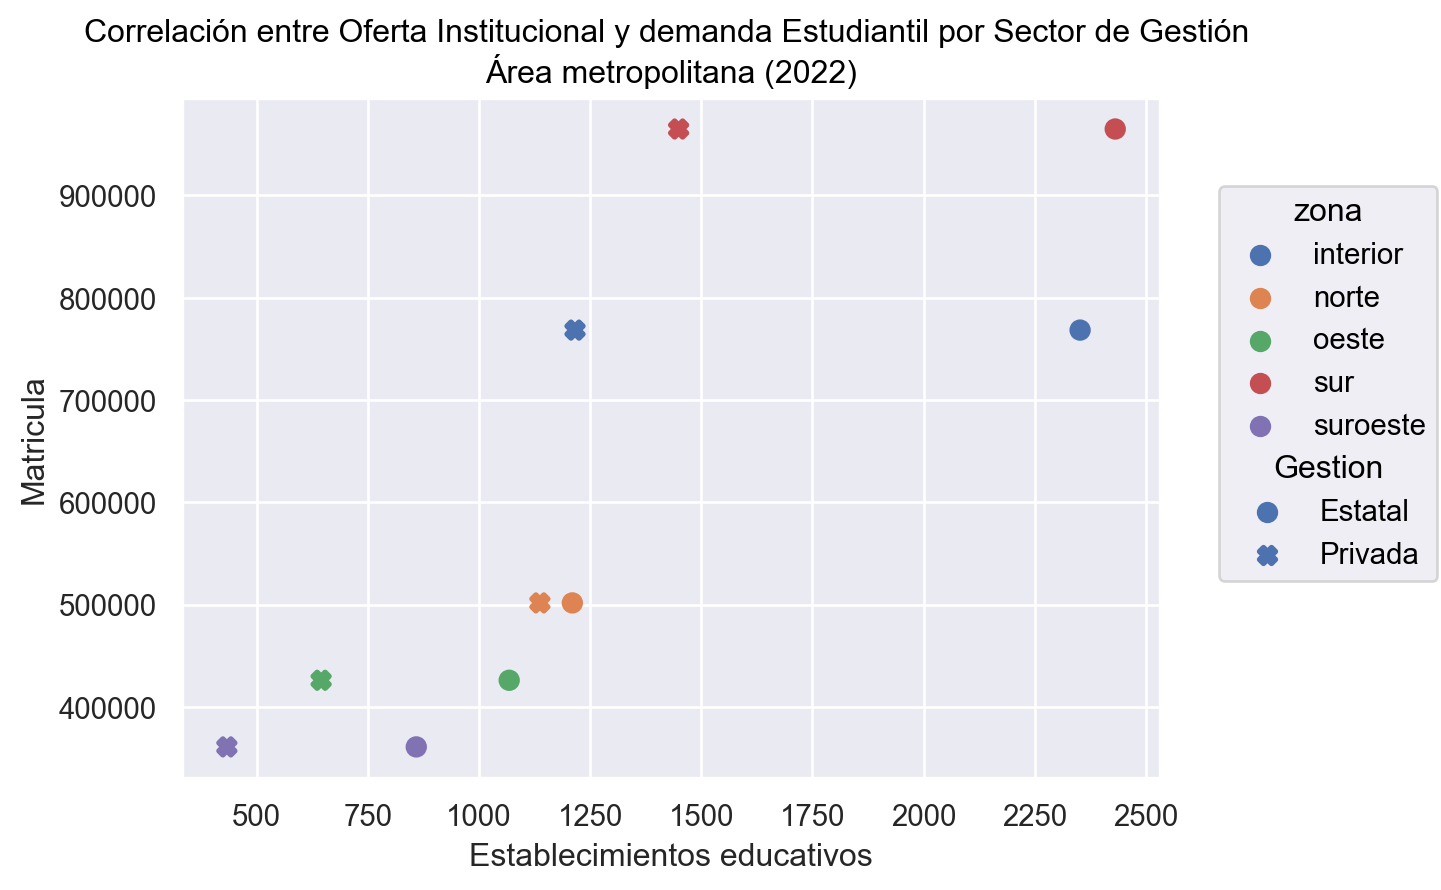

In [210]:
(so.Plot(grafico_gestion,x="colegios",y="matricula_total",color="zona",marker="Gestion")
    .add(so.Dot(edgewidth=2))
    .label(title="Correlación entre Oferta Institucional y demanda Estudiantil por Sector de Gestión \nÁrea metropolitana (2022)",x="Establecimientos educativos",y="Matricula"))

Analisis Nivel Primario por Zona
---

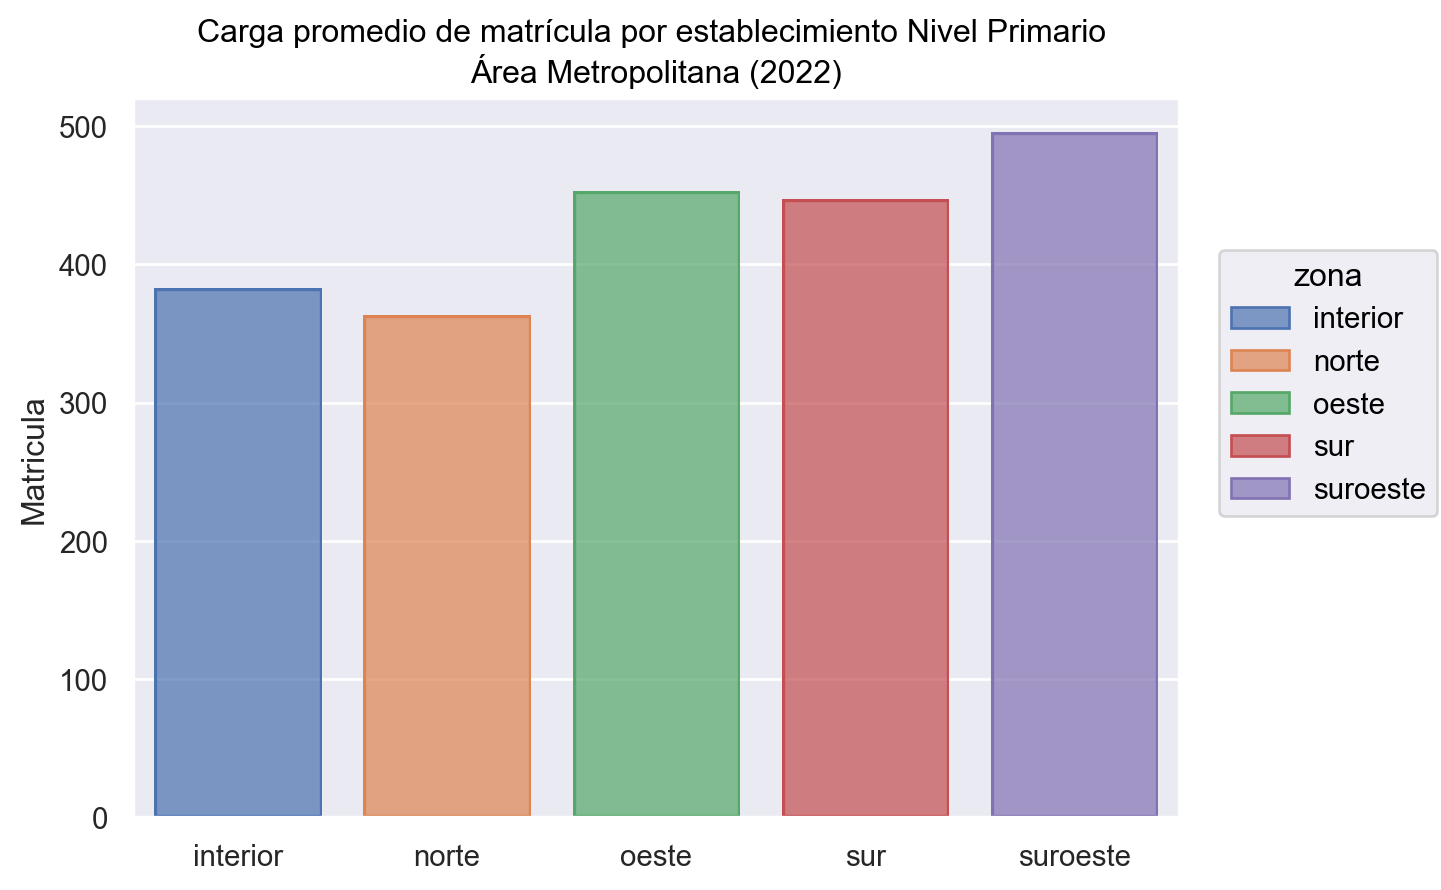

In [211]:
(so.Plot(df_2022_alumnos_colegio,x="zona",y=df_2022_alumnos_colegio["matricula_nivel_primario"]/df_2022_alumnos_colegio["unidades_de_servicio_nivel_primario"],color="zona")
 .add(so.Bar())
 .label(title="Carga promedio de matrícula por establecimiento Nivel Primario \nÁrea Metropolitana (2022)",y="Matricula",x=None))

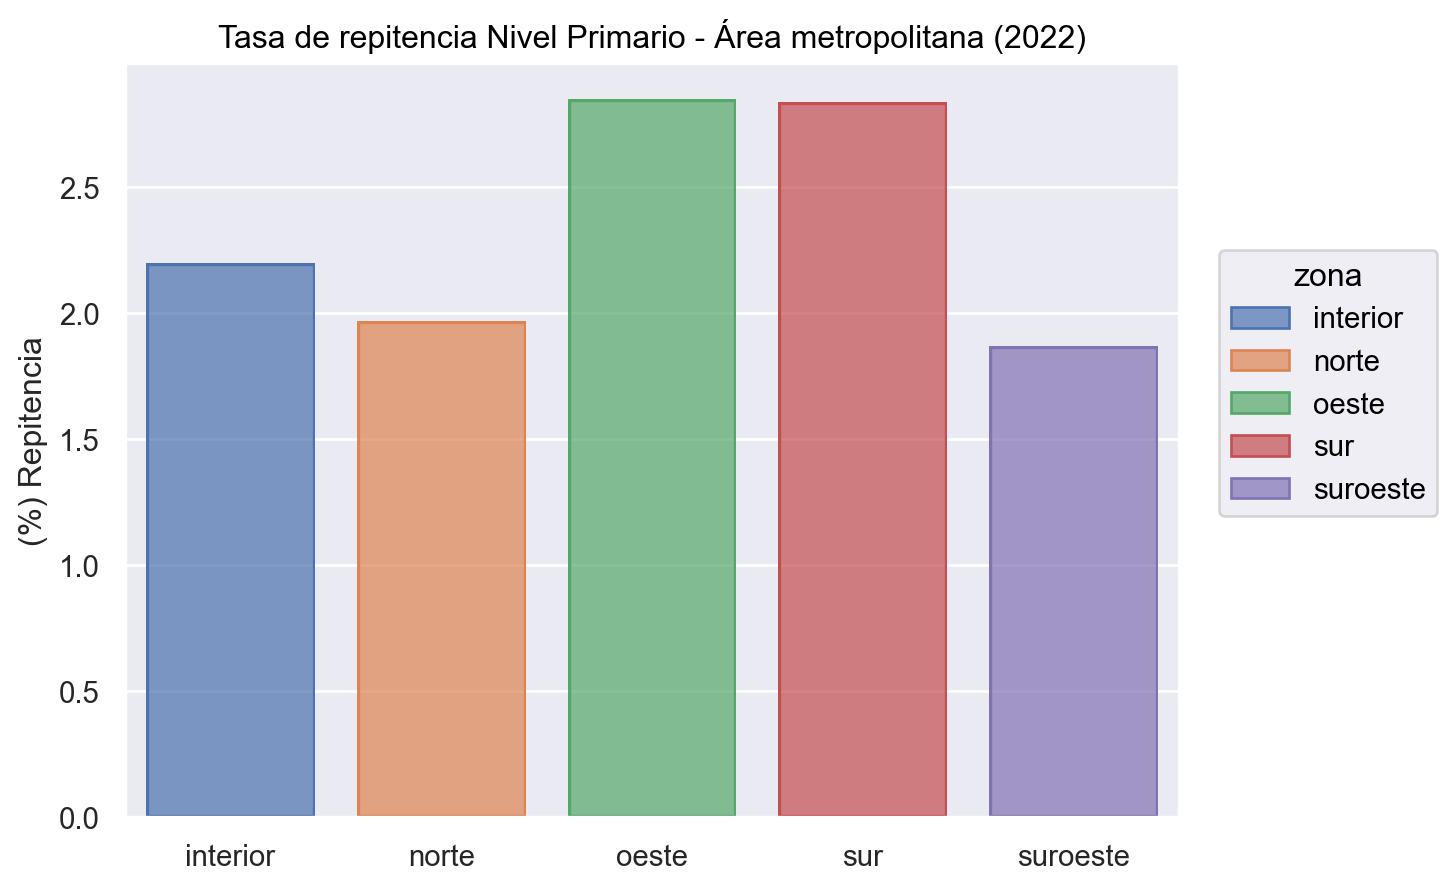

In [212]:
(so.Plot(df_2022_repitencia,x="zona",y="repitencia_primaria",color="zona")
    .add(so.Bar())
    .label(title="Tasa de repitencia Nivel Primario - Área metropolitana (2022)",x=None,y="(%) Repitencia"))

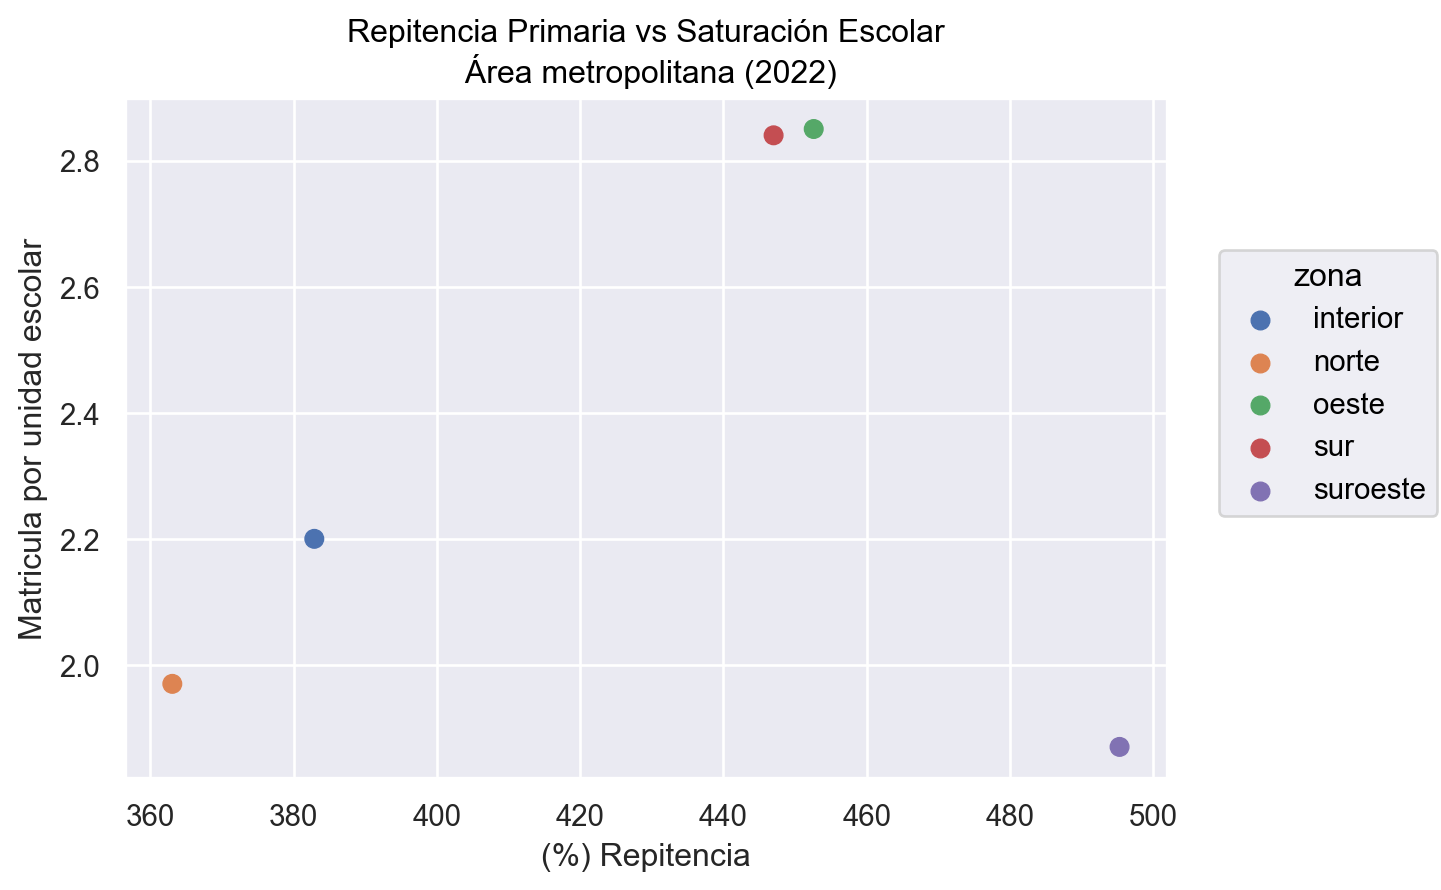

In [213]:
(so.Plot(df_2022_repitencia,x=df_2022_alumnos_colegio["matricula_nivel_primario"]/df_2022_alumnos_colegio["unidades_de_servicio_nivel_primario"],y="repitencia_primaria",color="zona")
 .add(so.Dot(pointsize=7,marker="o"))
 .label(title="Repitencia Primaria vs Saturación Escolar\n Área metropolitana (2022)",y="Matricula por unidad escolar",x="(%) Repitencia"))

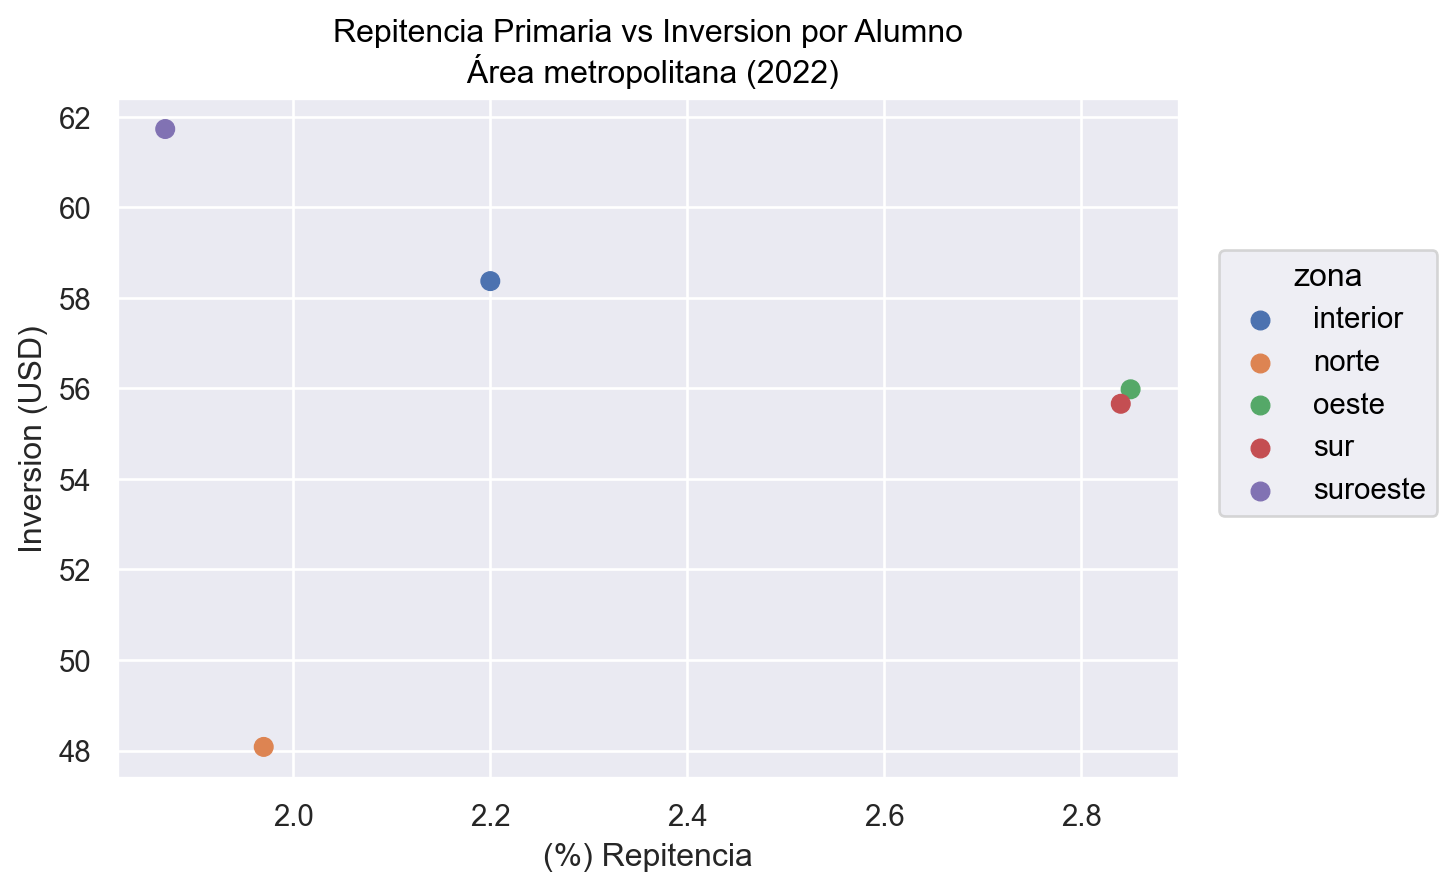

In [214]:
(so.Plot(df_2022_repitencia,x="repitencia_primaria",y=df_2022_poblacion_inversion["inversion_alumno"],color="zona") 
    .add(so.Dot(pointsize=7))
    .label(title="Repitencia Primaria vs Inversion por Alumno\n Área metropolitana (2022)",x="(%) Repitencia",y="Inversion (USD)"))

Analisis Nivel Secundario por Zona
---

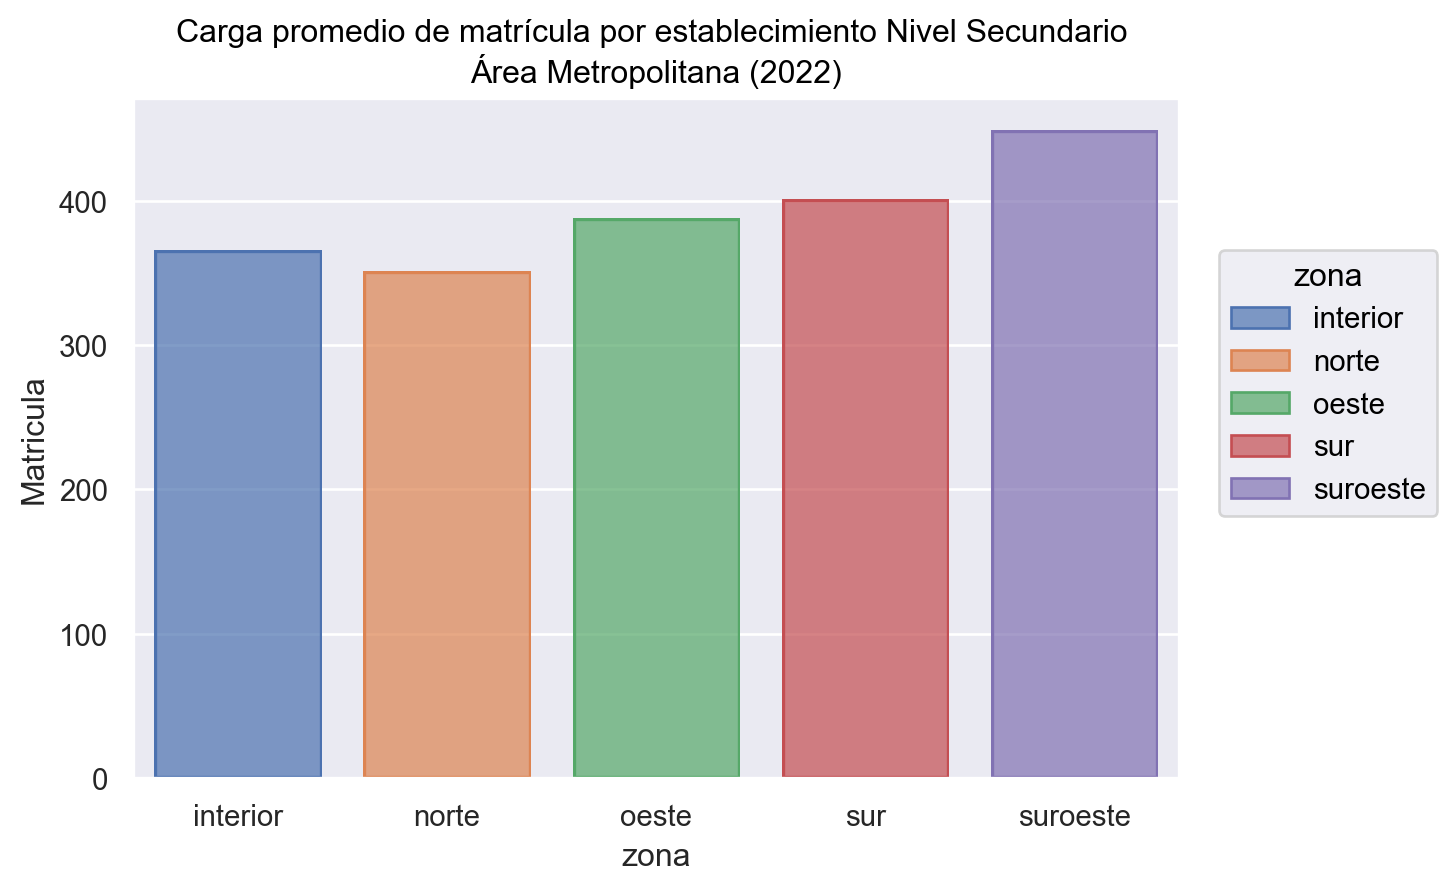

In [215]:
(so.Plot(df_2022_alumnos_colegio,x="zona",y=df_2022_alumnos_colegio["matricula_nivel_secundario"]/df_2022_alumnos_colegio["unidades_de_servicio_nivel_secundario"],color="zona")
    .add(so.Bar())
    .label(title="Carga promedio de matrícula por establecimiento Nivel Secundario \nÁrea Metropolitana (2022)",y="Matricula"))

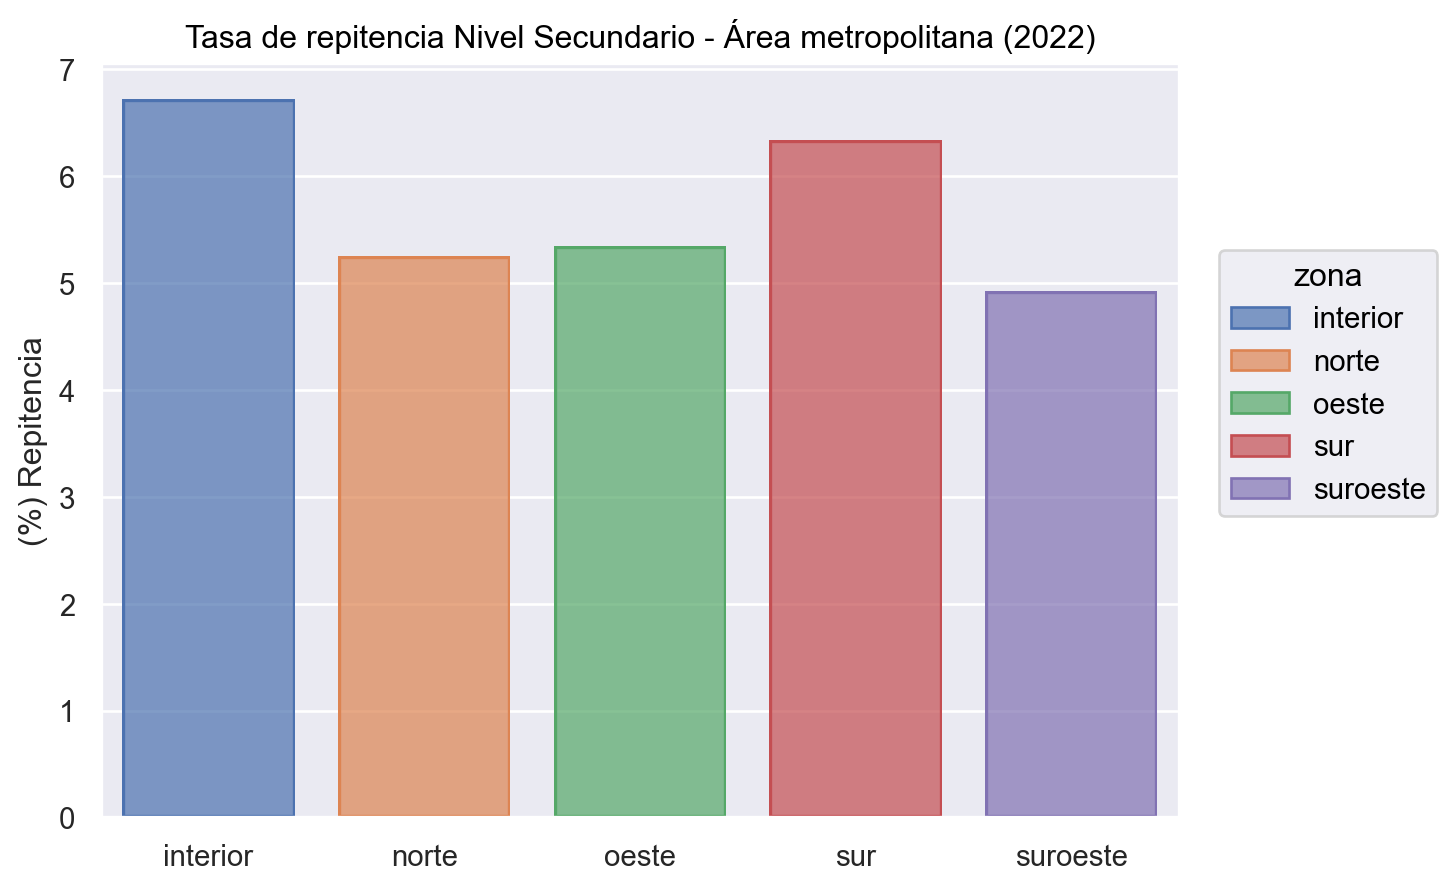

In [216]:
(so.Plot(df_2022_repitencia,x="zona",y="repitencia_secundaria",color="zona")
    .add(so.Bar())
    .label(title="Tasa de repitencia Nivel Secundario - Área metropolitana (2022)",x=None,y="(%) Repitencia"))

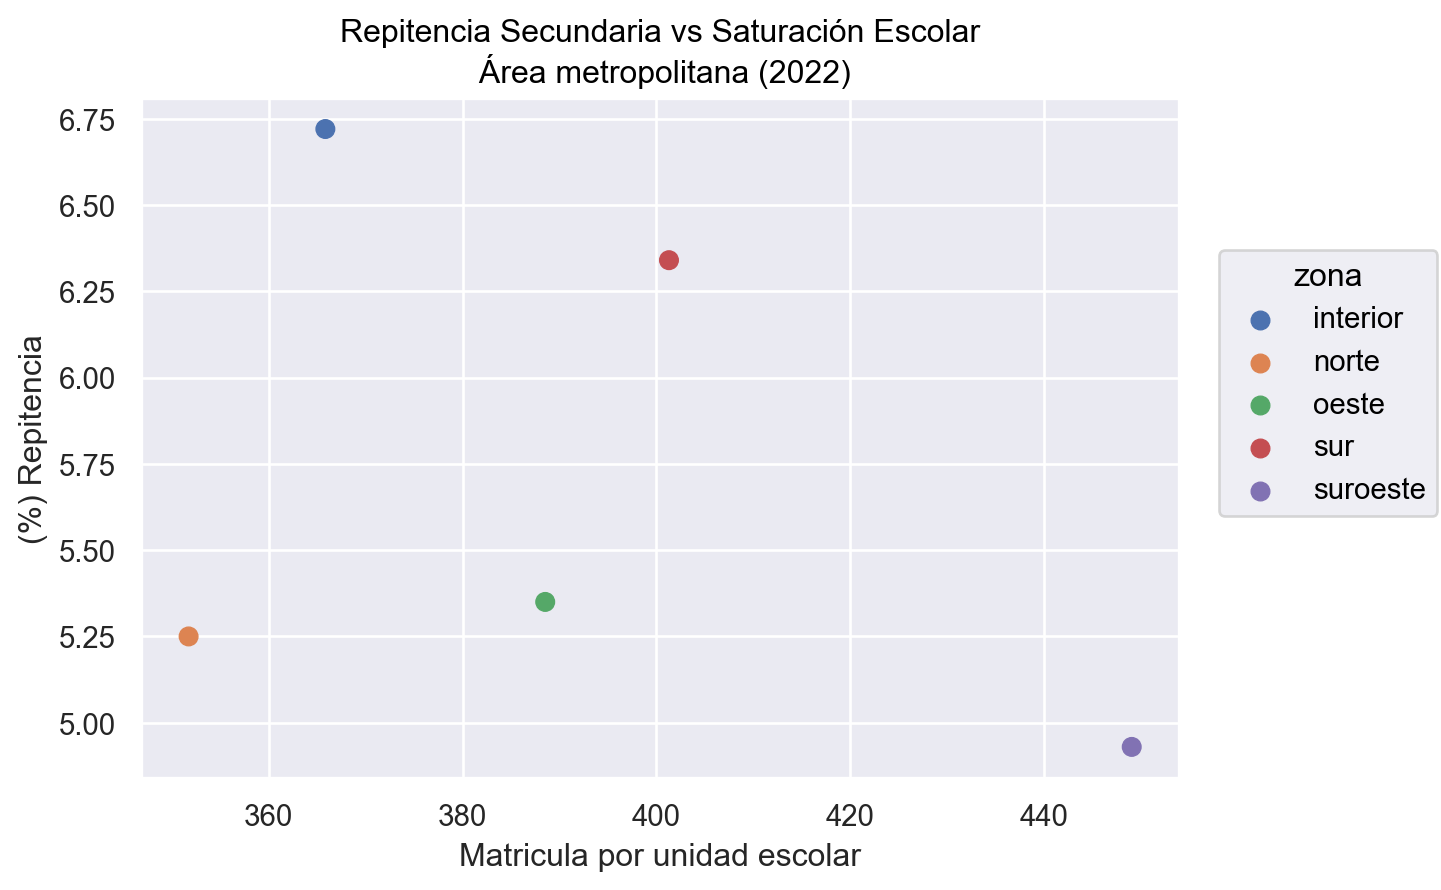

In [217]:
(so.Plot(df_2022_repitencia,x=df_2022_alumnos_colegio["matricula_nivel_secundario"]/df_2022_alumnos_colegio["unidades_de_servicio_nivel_secundario"],y="repitencia_secundaria",color="zona")
    .add(so.Dot(pointsize=7,marker="o"))
    .label(title="Repitencia Secundaria vs Saturación Escolar\n Área metropolitana (2022)",y="(%) Repitencia",x="Matricula por unidad escolar",))

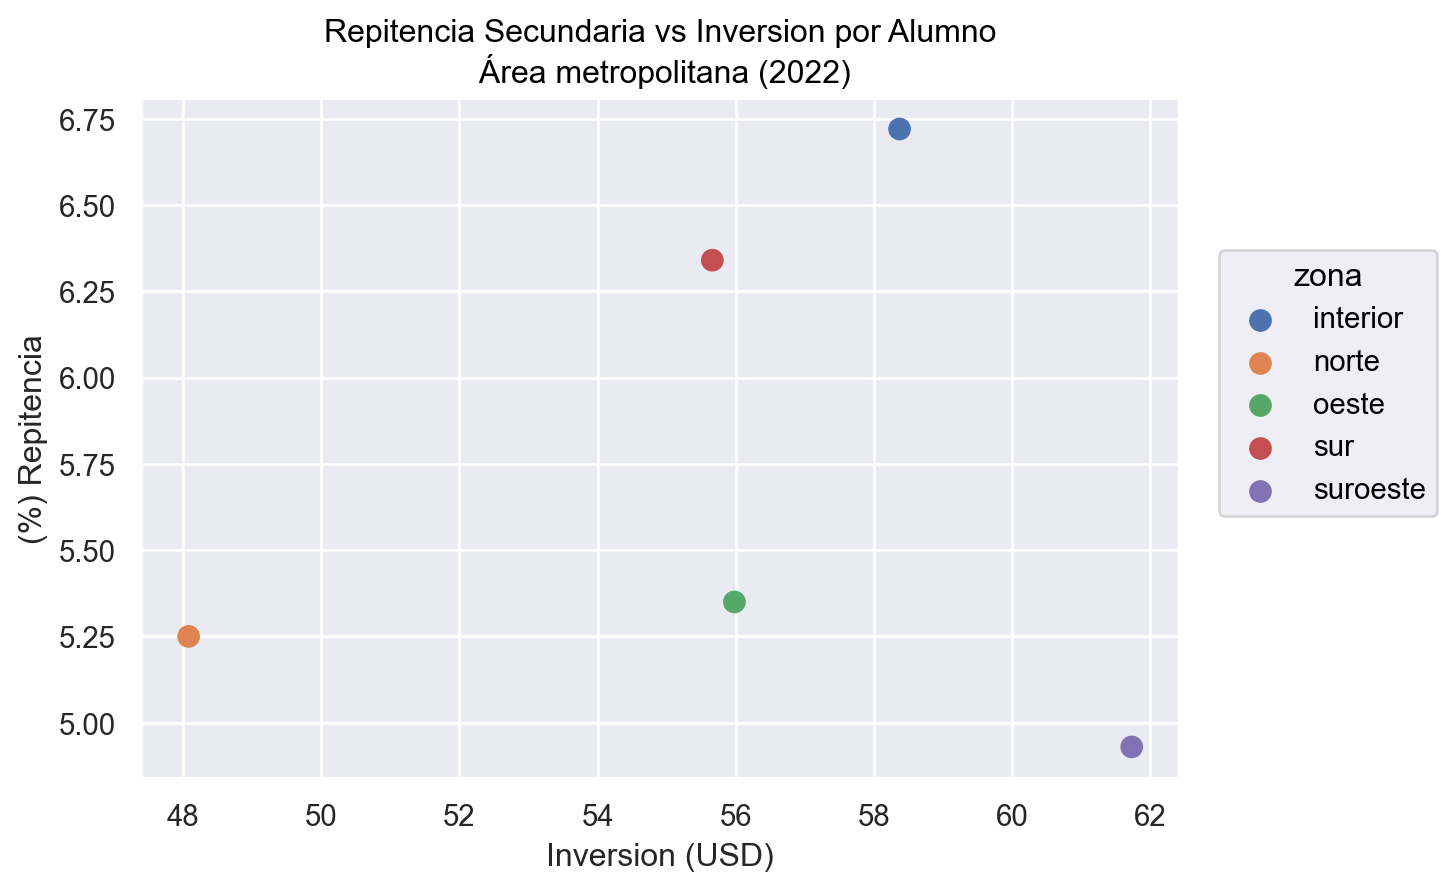

In [218]:
(so.Plot(df_2022_repitencia,x=df_2022_poblacion_inversion["inversion_alumno"],y="repitencia_secundaria",color="zona") 
    .add(so.Dot(pointsize=8))
    .label(title="Repitencia Secundaria vs Inversion por Alumno\n Área metropolitana (2022)",y="(%) Repitencia",x="Inversion (USD)"))

**Analisis Exploratorio: Área Metropolitana(2013-2022)** 
---

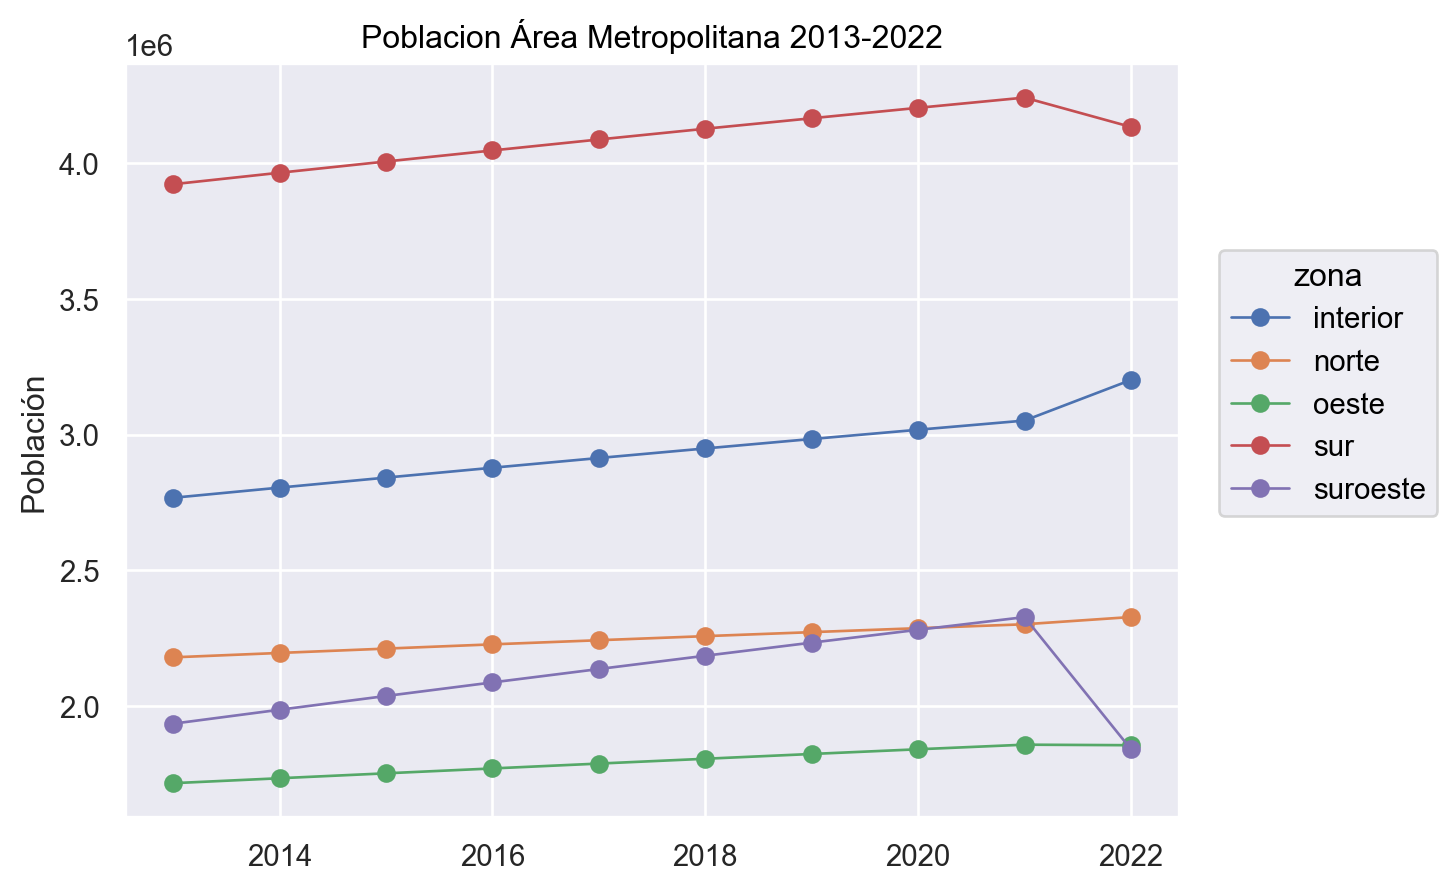

In [219]:
(so.Plot(df_poblacion_inversion,x="anio",y="poblacion_total",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Poblacion Área Metropolitana 2013-2022",x=None,y="Población"))

Nivel Primario
--

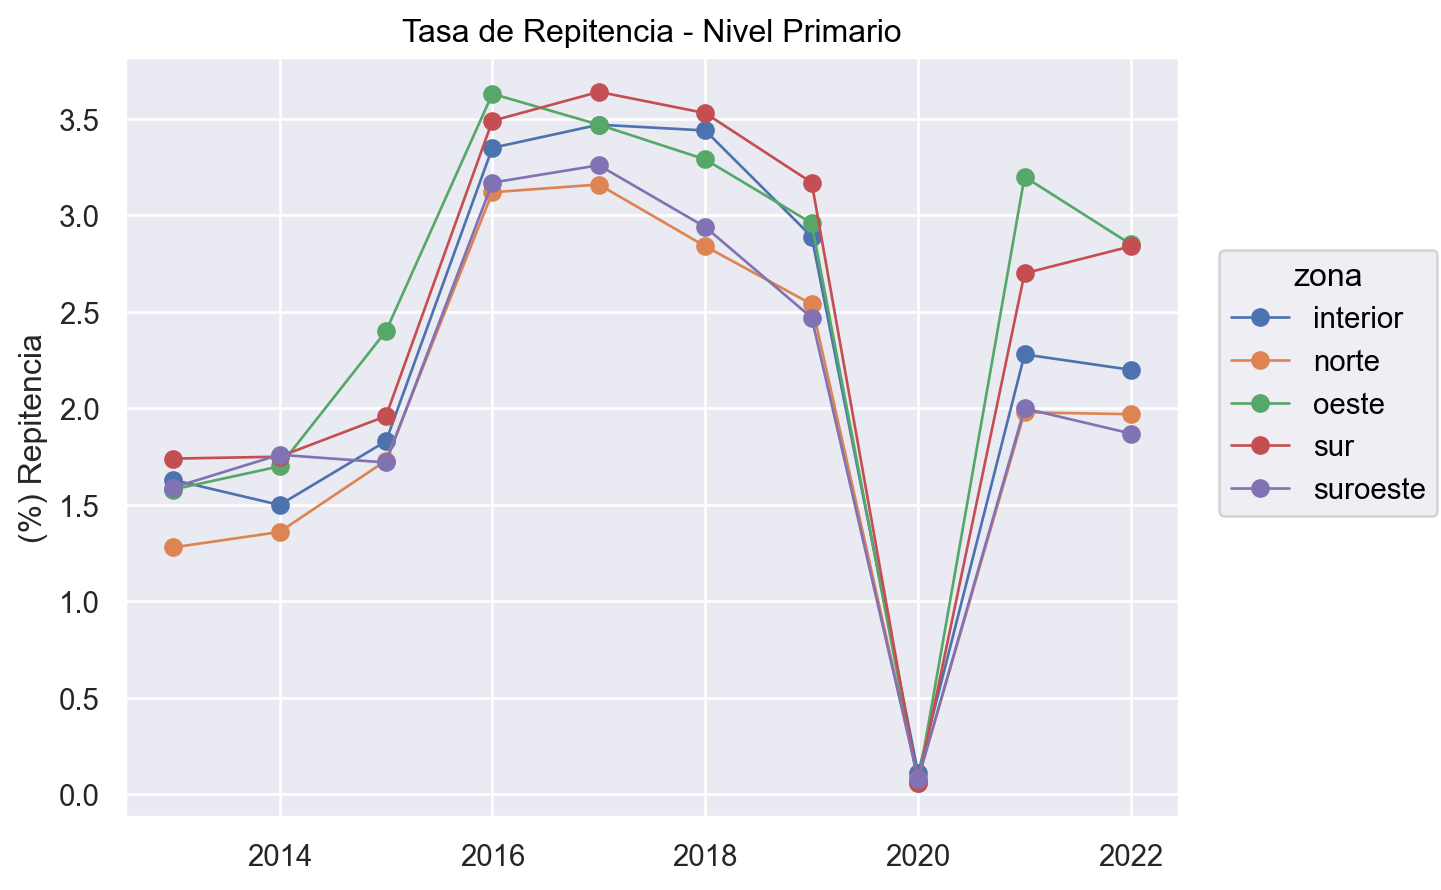

In [220]:
(so.Plot(df_repitencia,x="anio",y="repitencia_primaria",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Tasa de Repitencia - Nivel Primario",x=None,y="(%) Repitencia"))

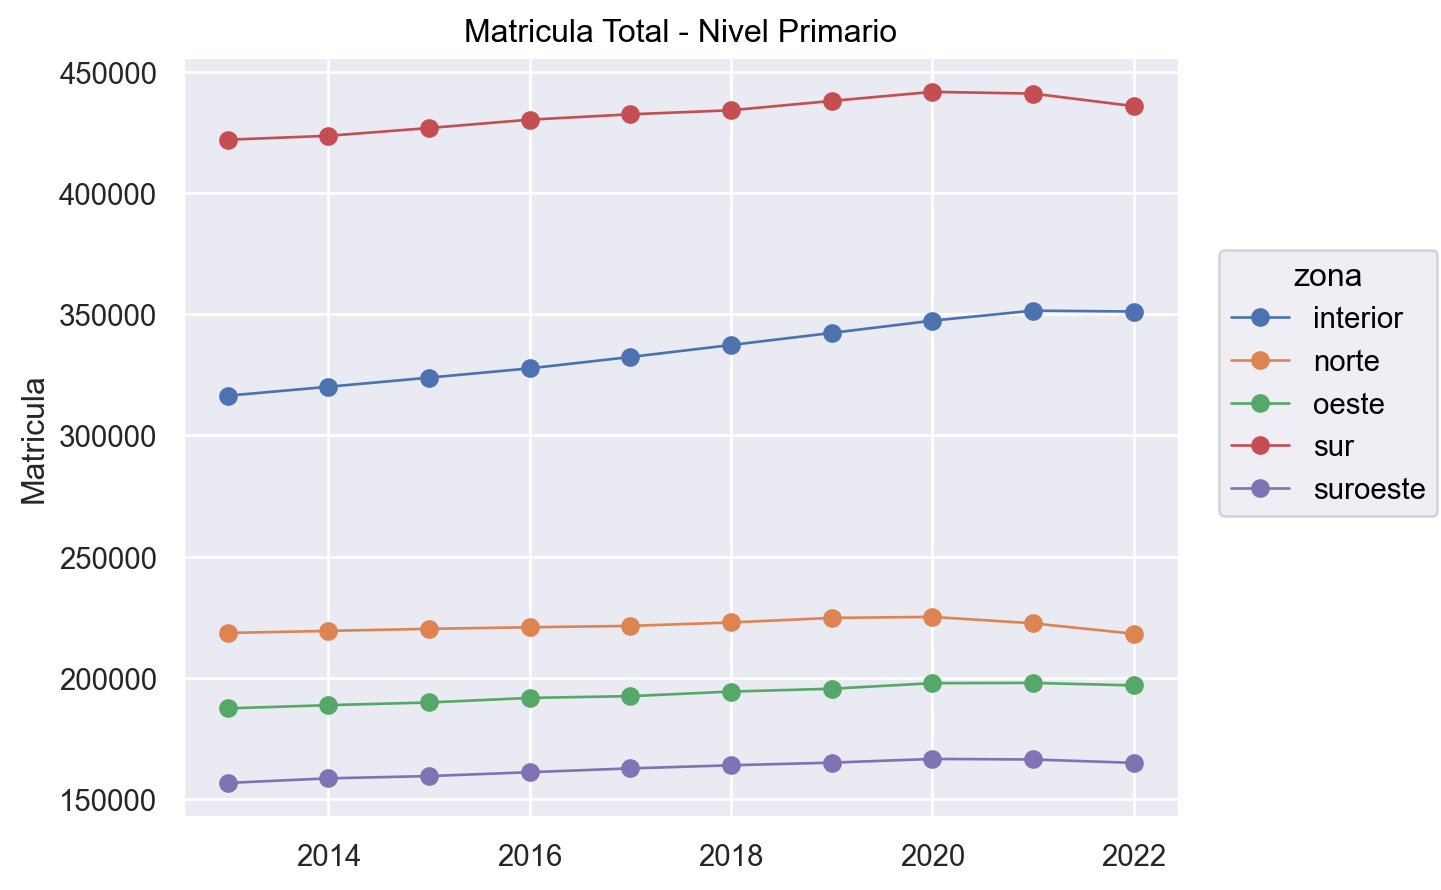

In [221]:
(so.Plot(df_alumnos_colegio,x="anio",y="matricula_nivel_primario",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Matricula Total - Nivel Primario",y="Matricula",x=None))

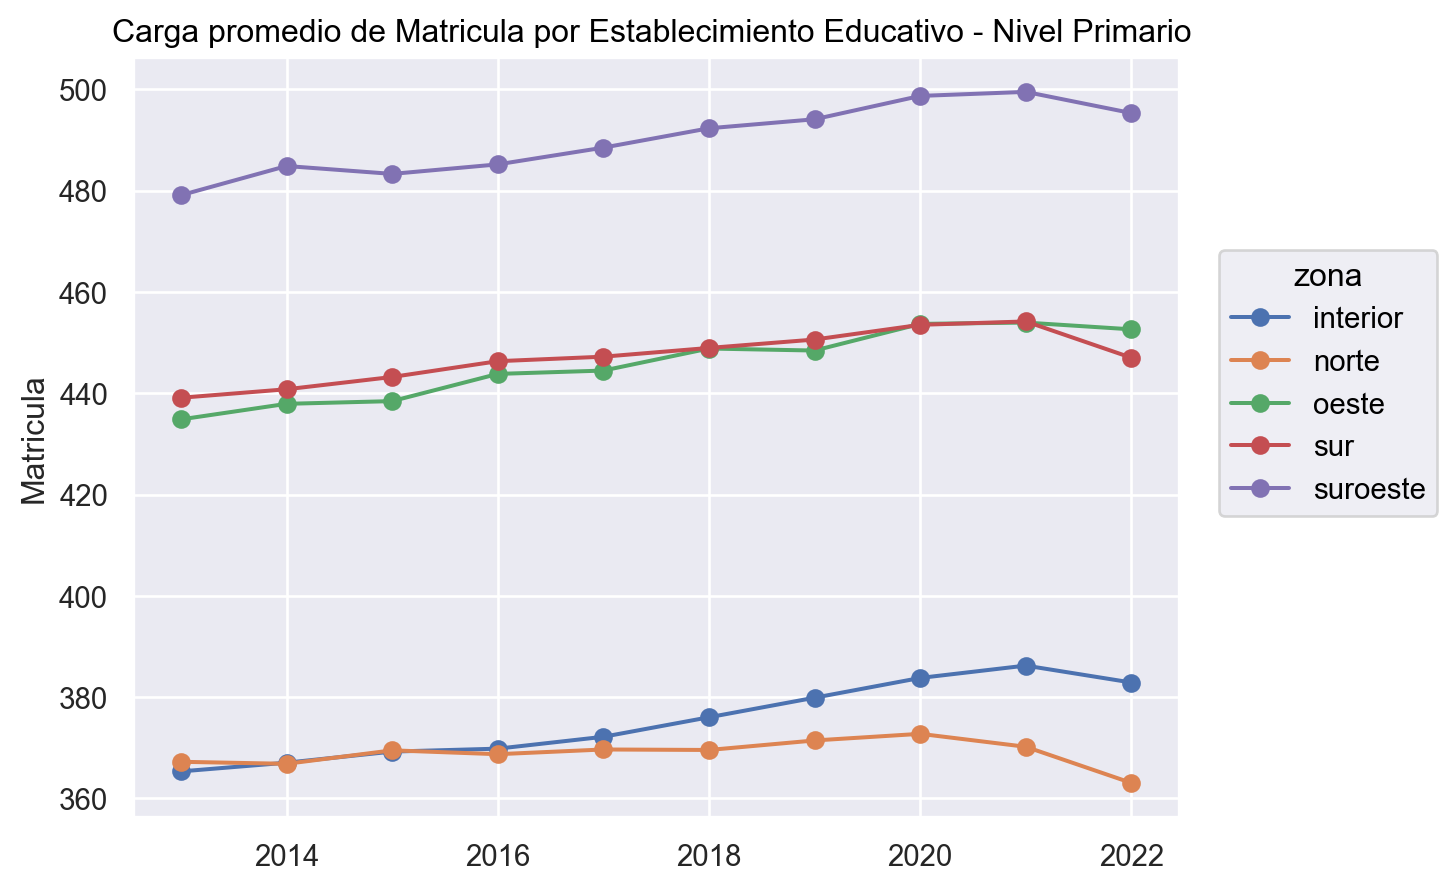

In [222]:
(so.Plot(df_alumnos_colegio,x="anio",y=df_alumnos_colegio["matricula_nivel_primario"]/df_alumnos_colegio["unidades_de_servicio_nivel_primario"],color="zona")
 .add(so.Line(marker="o"))
 .label(title="Carga promedio de Matricula por Establecimiento Educativo - Nivel Primario ",y="Matricula",x=None))

Nivel Secundario
--

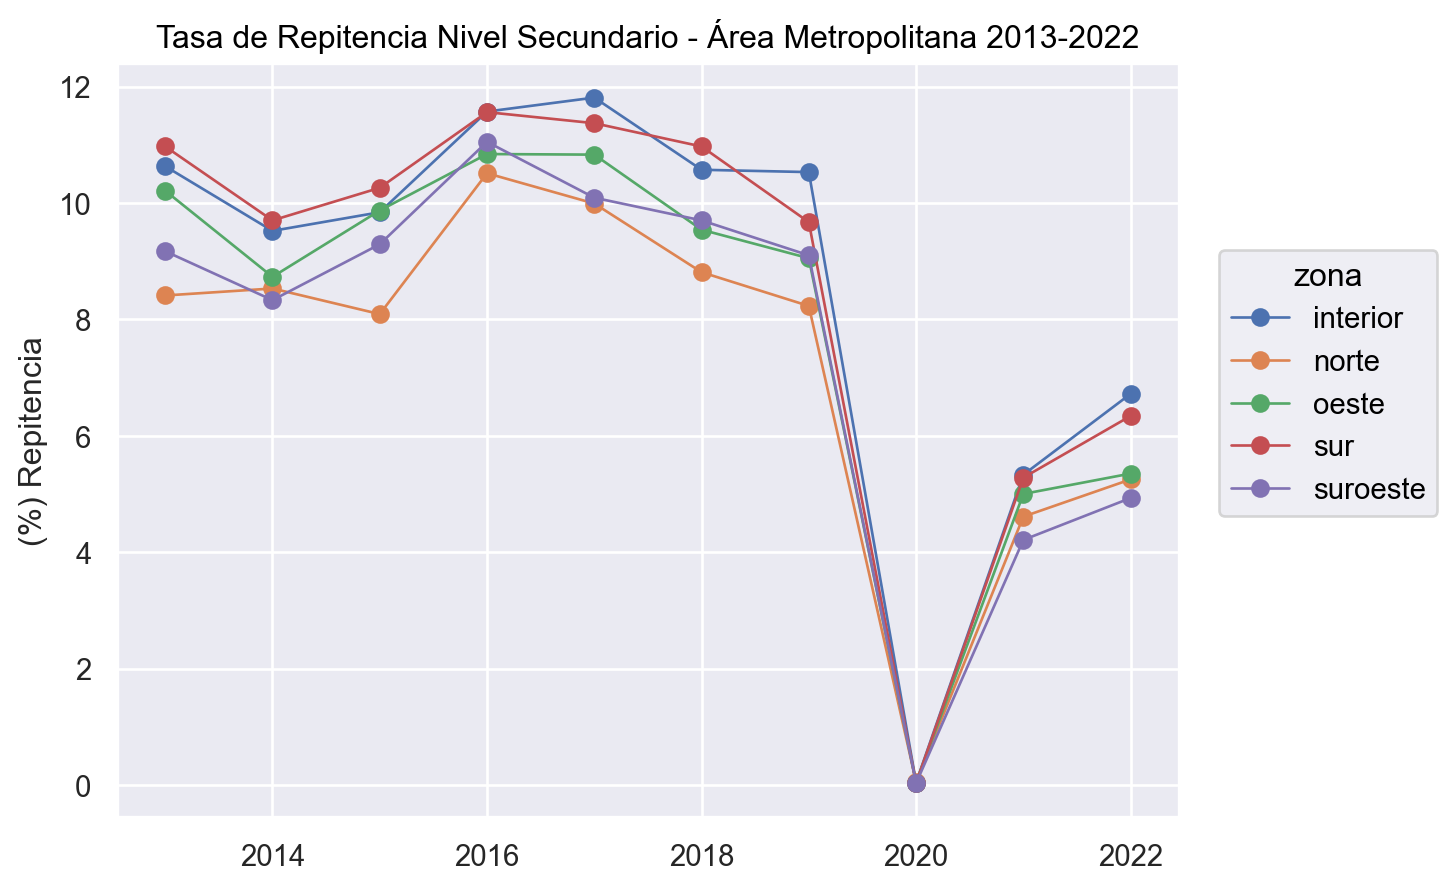

In [223]:
(so.Plot(df_repitencia,x="anio",y="repitencia_secundaria",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Tasa de Repitencia Nivel Secundario - Área Metropolitana 2013-2022",x=None,y="(%) Repitencia"))

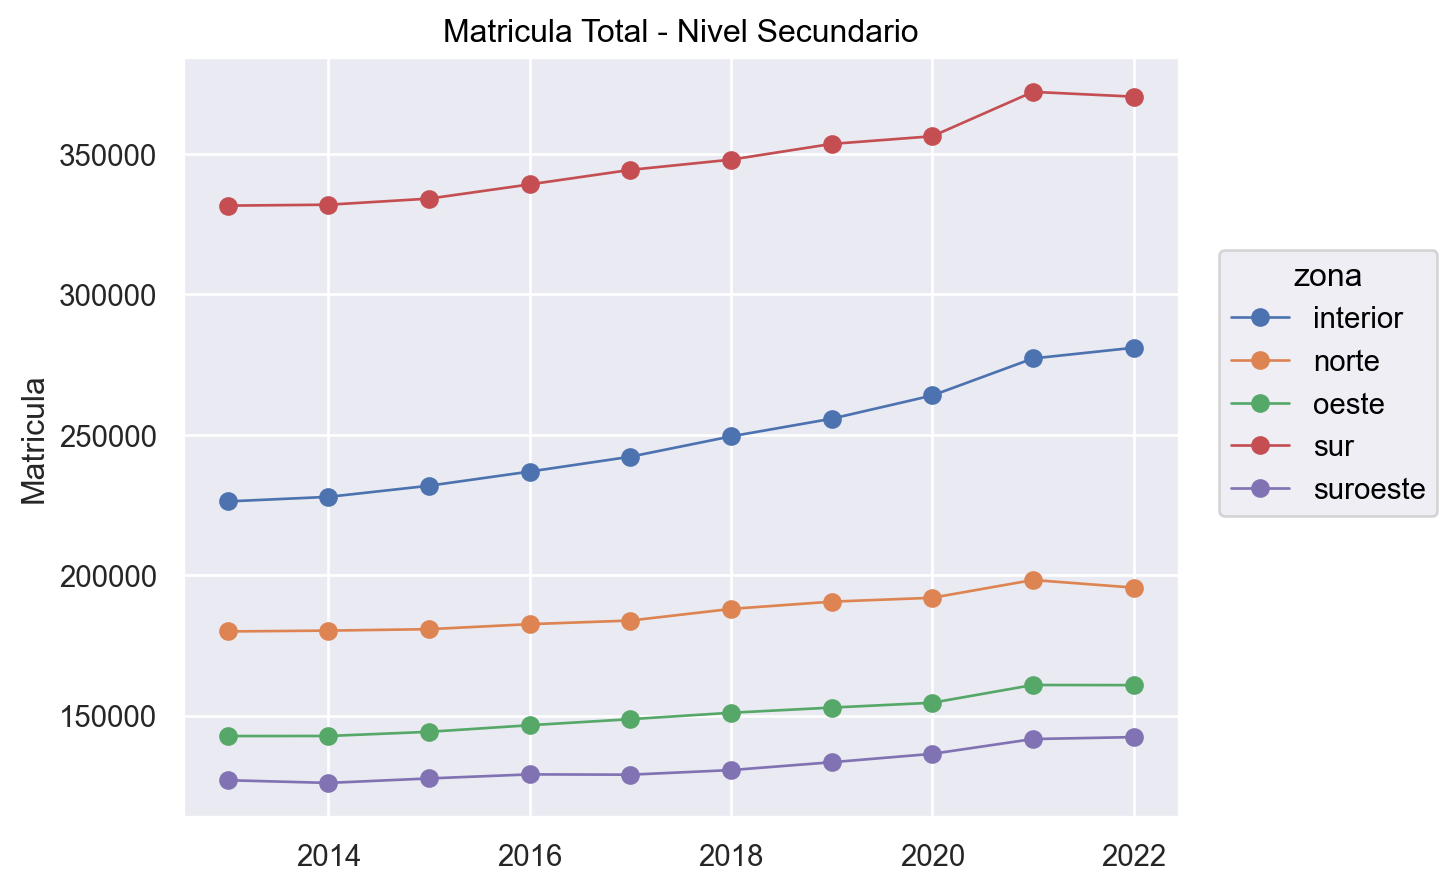

In [224]:
(so.Plot(df_alumnos_colegio,x="anio",y="matricula_nivel_secundario",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Matricula Total - Nivel Secundario",y="Matricula",x=None))

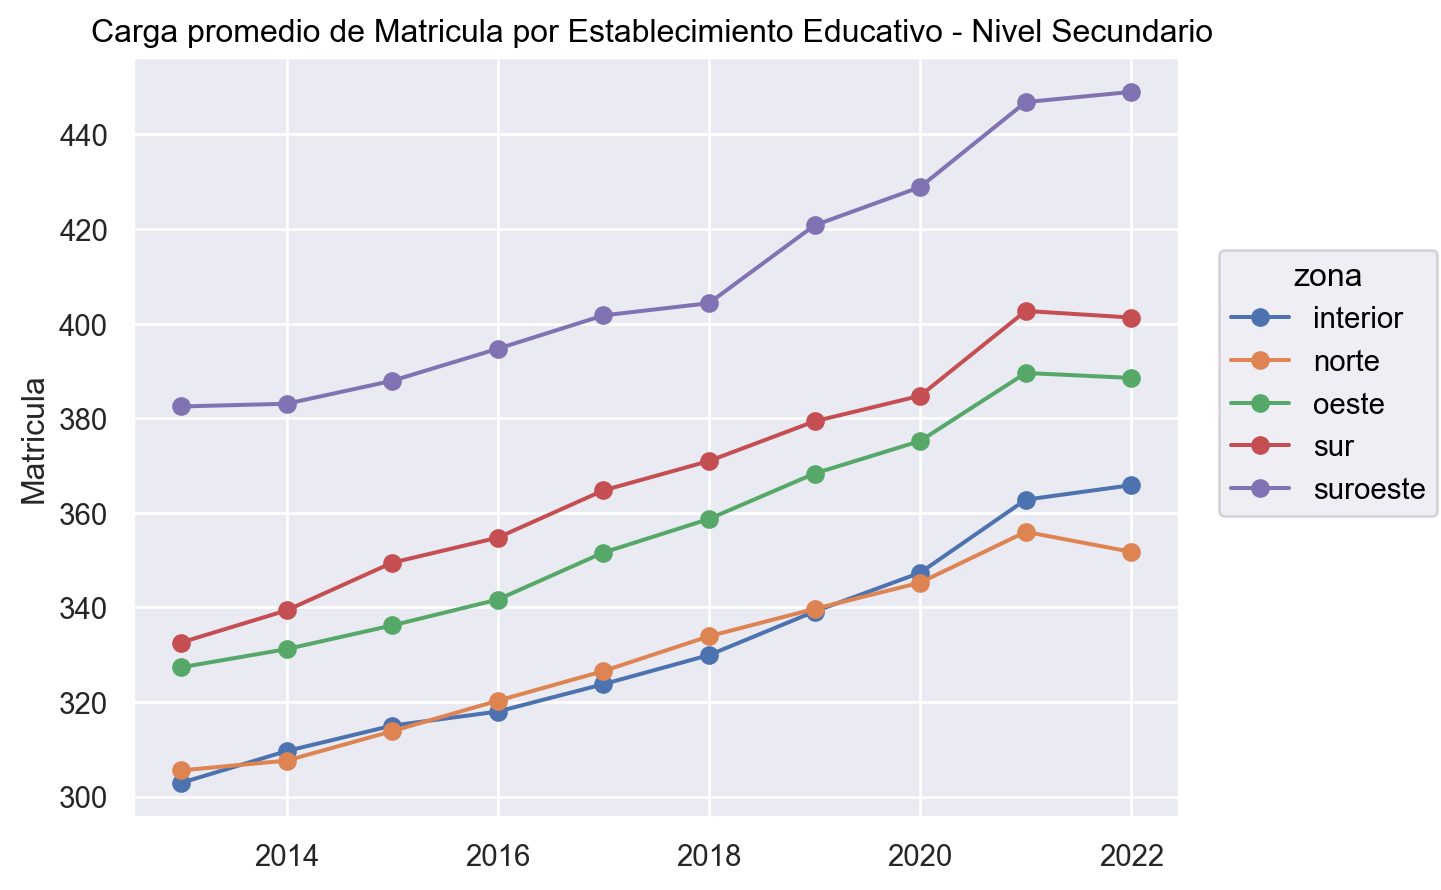

In [225]:
(so.Plot(df_alumnos_colegio,x="anio",y=df_alumnos_colegio["matricula_nivel_secundario"]/df_alumnos_colegio["unidades_de_servicio_nivel_secundario"],color="zona")
 .add(so.Line(marker="o"))
 .label(title="Carga promedio de Matricula por Establecimiento Educativo - Nivel Secundario ",y="Matricula",x=None))

Analisis General
--

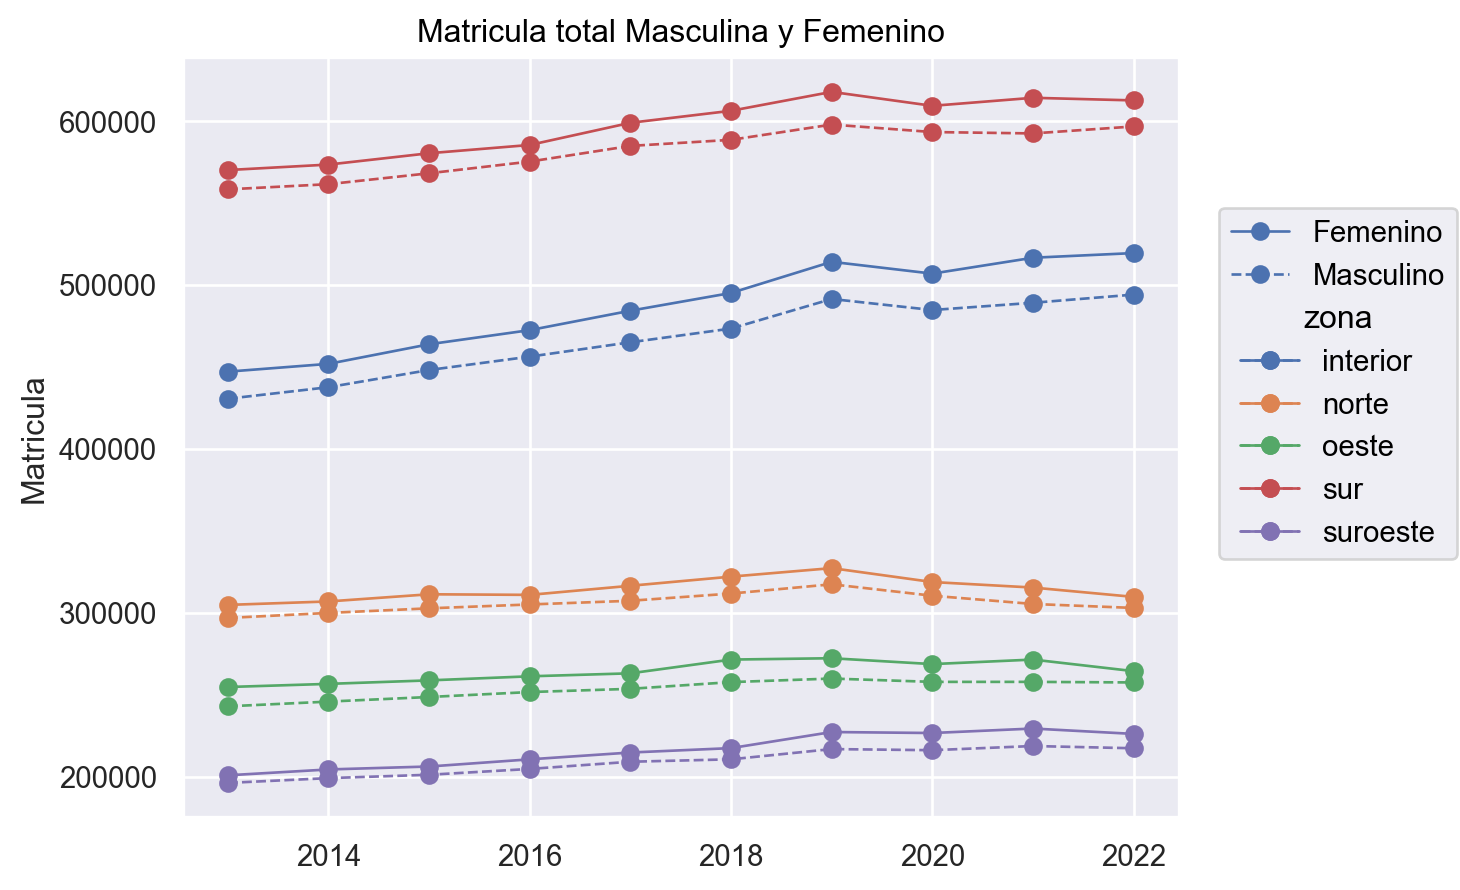

In [226]:
(so.Plot(df_alumnos_colegio,x="anio",color="zona")
    .add(so.Line(marker="o",linewidth=1),y="matricula_sexo_femenino",label="Femenino")
    .add(so.Line(marker="o",linewidth=1,linestyle="--"),y="matricula_sexo_masculino",label="Masculino")    
    .label(title="Matricula total Masculina y Femenino",y="Matricula",x=None))

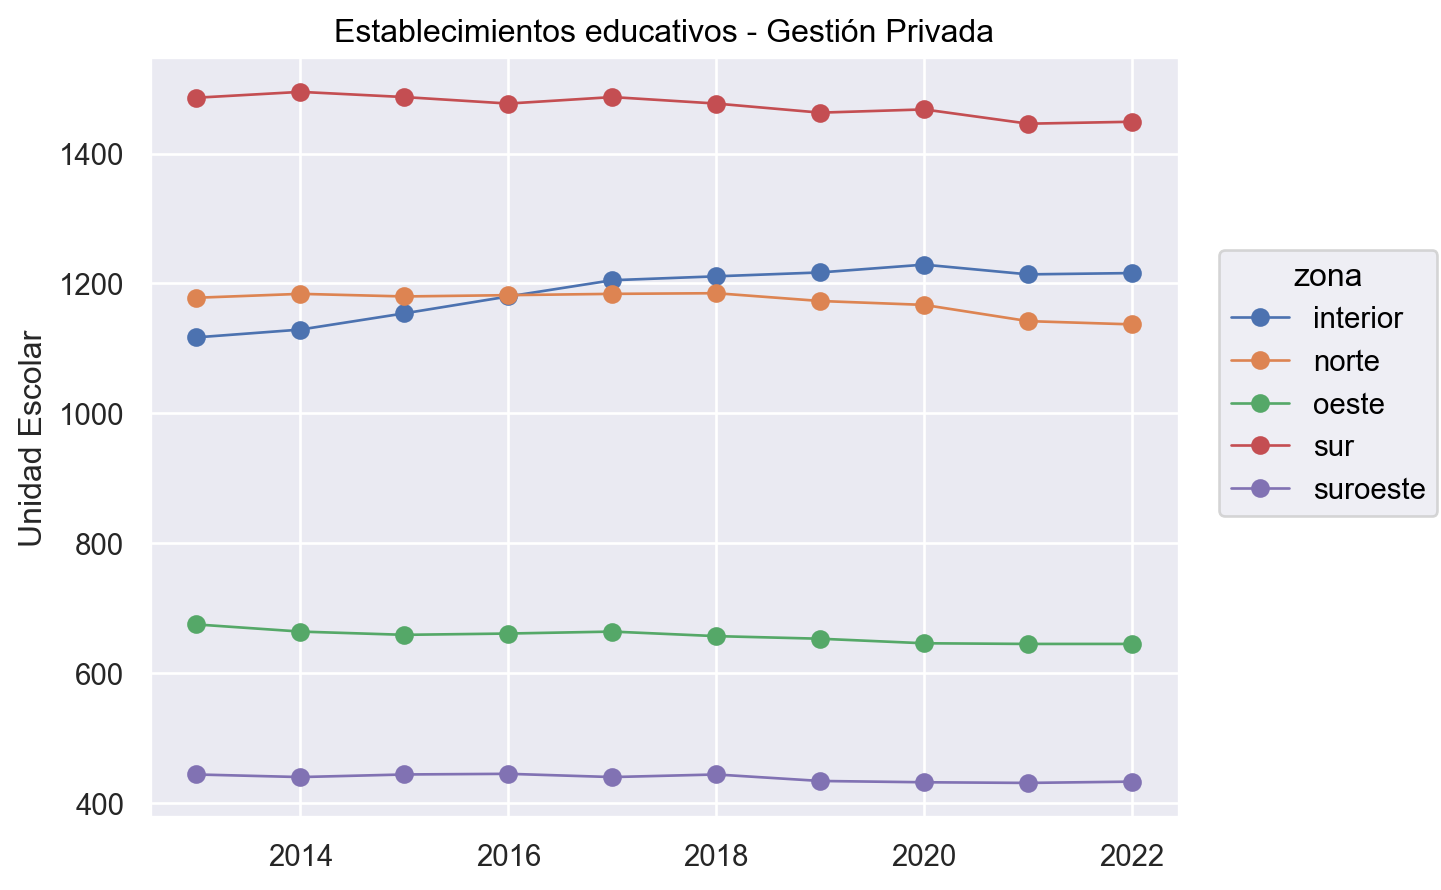

In [227]:
(so.Plot(df_alumnos_colegio,x="anio",y="sector_de_gestion_privada",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Establecimientos educativos - Gestión Privada",y="Unidad Escolar",x=None))
    

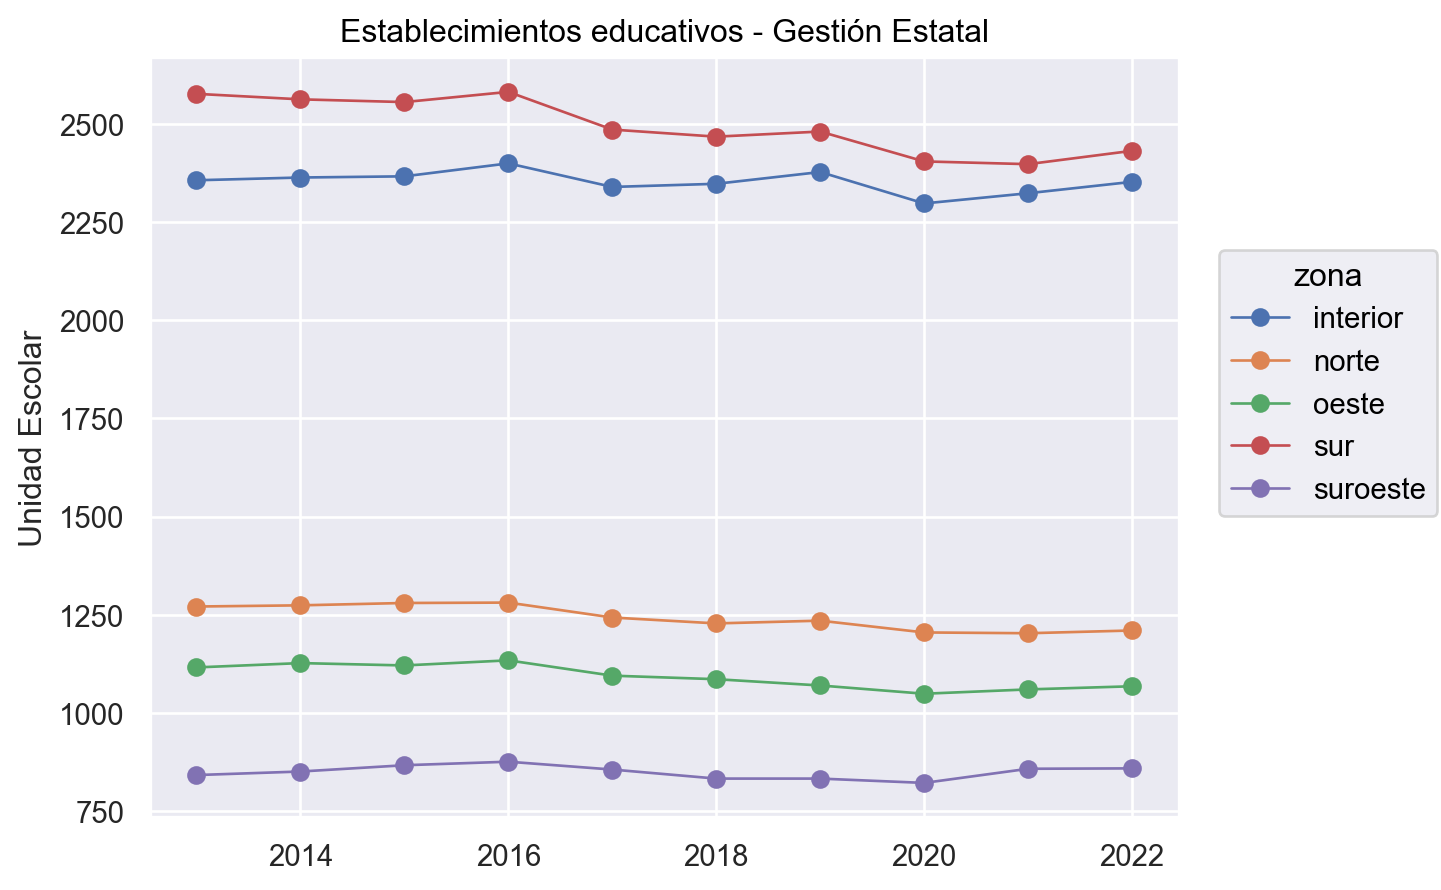

In [228]:
(so.Plot(df_alumnos_colegio,x="anio",y="sector_de_gestion_estatal",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Establecimientos educativos - Gestión Estatal",y="Unidad Escolar",x=None))
    

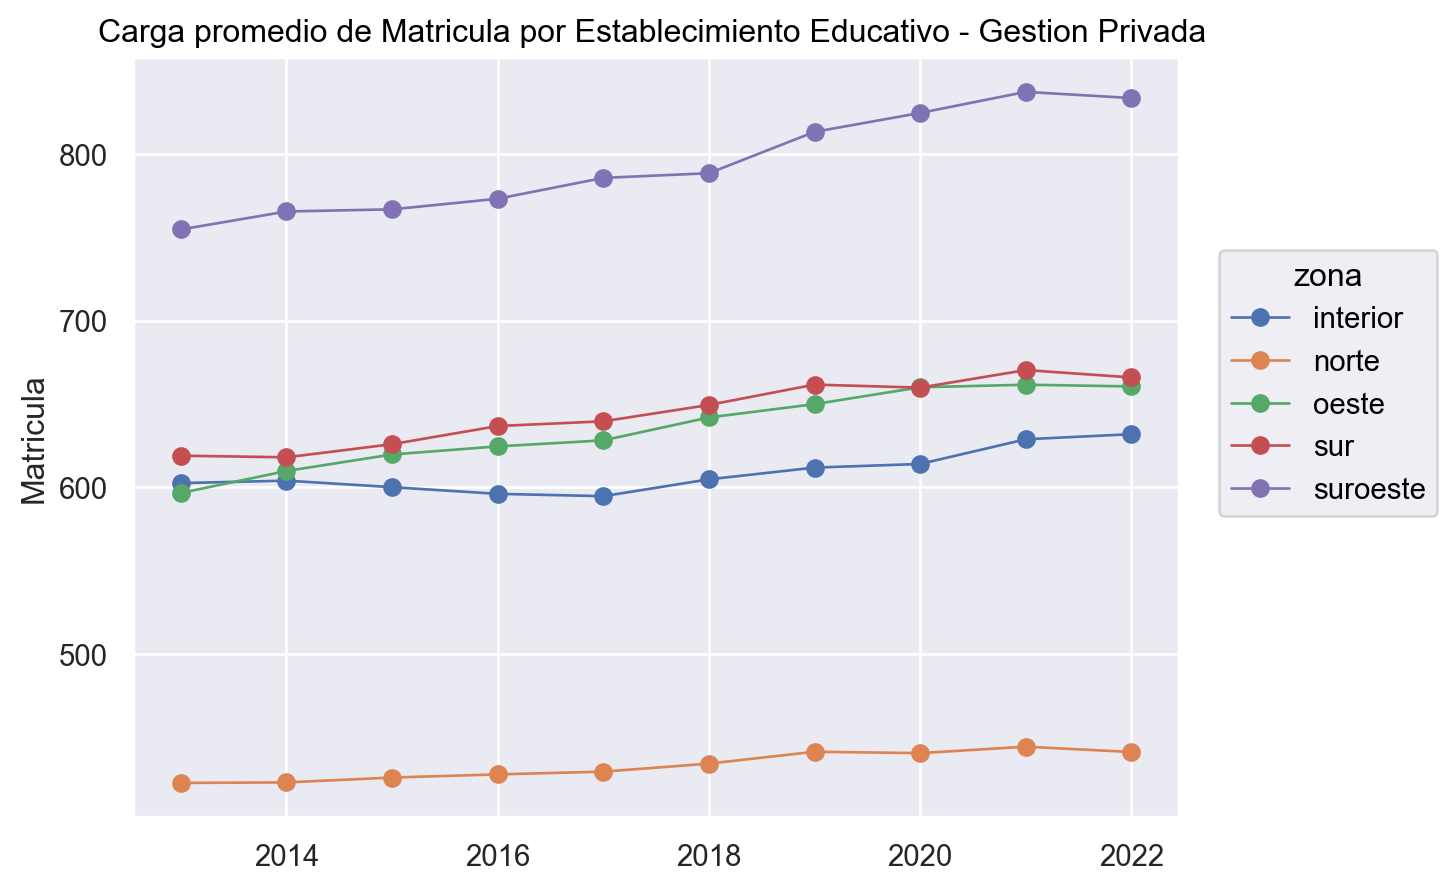

In [229]:
(so.Plot(df_alumnos_colegio,x="anio",y=df_alumnos_colegio["matricula_total"]/df_alumnos_colegio["sector_de_gestion_privada"],color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Carga promedio de Matricula por Establecimiento Educativo - Gestion Privada ",y="Matricula",x=None))

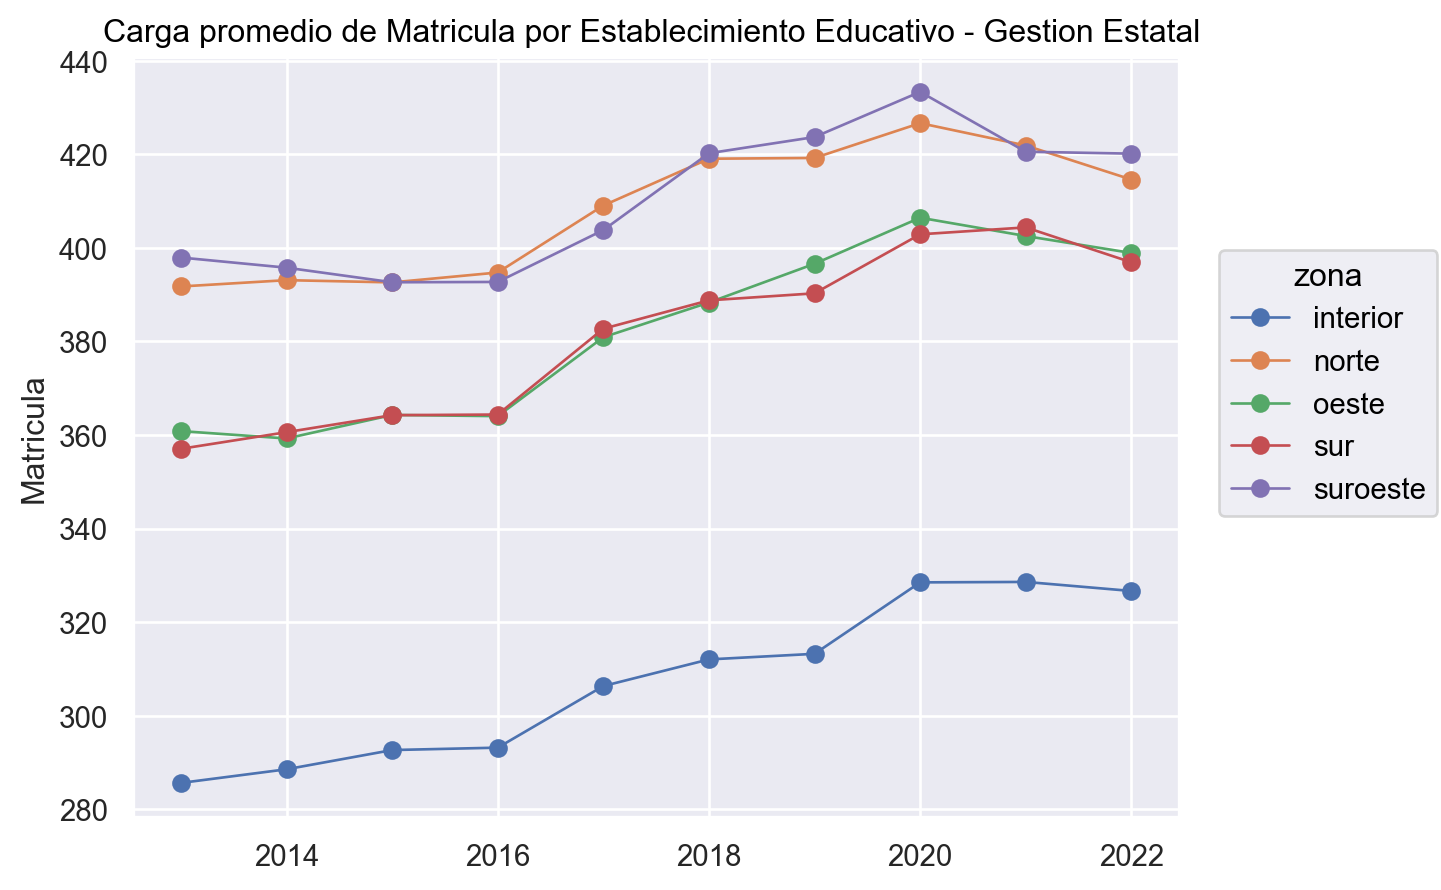

In [230]:
(so.Plot(df_alumnos_colegio,x="anio",y=df_alumnos_colegio["matricula_total"]/df_alumnos_colegio["sector_de_gestion_estatal"],color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Carga promedio de Matricula por Establecimiento Educativo - Gestion Estatal ",y="Matricula",x=None))

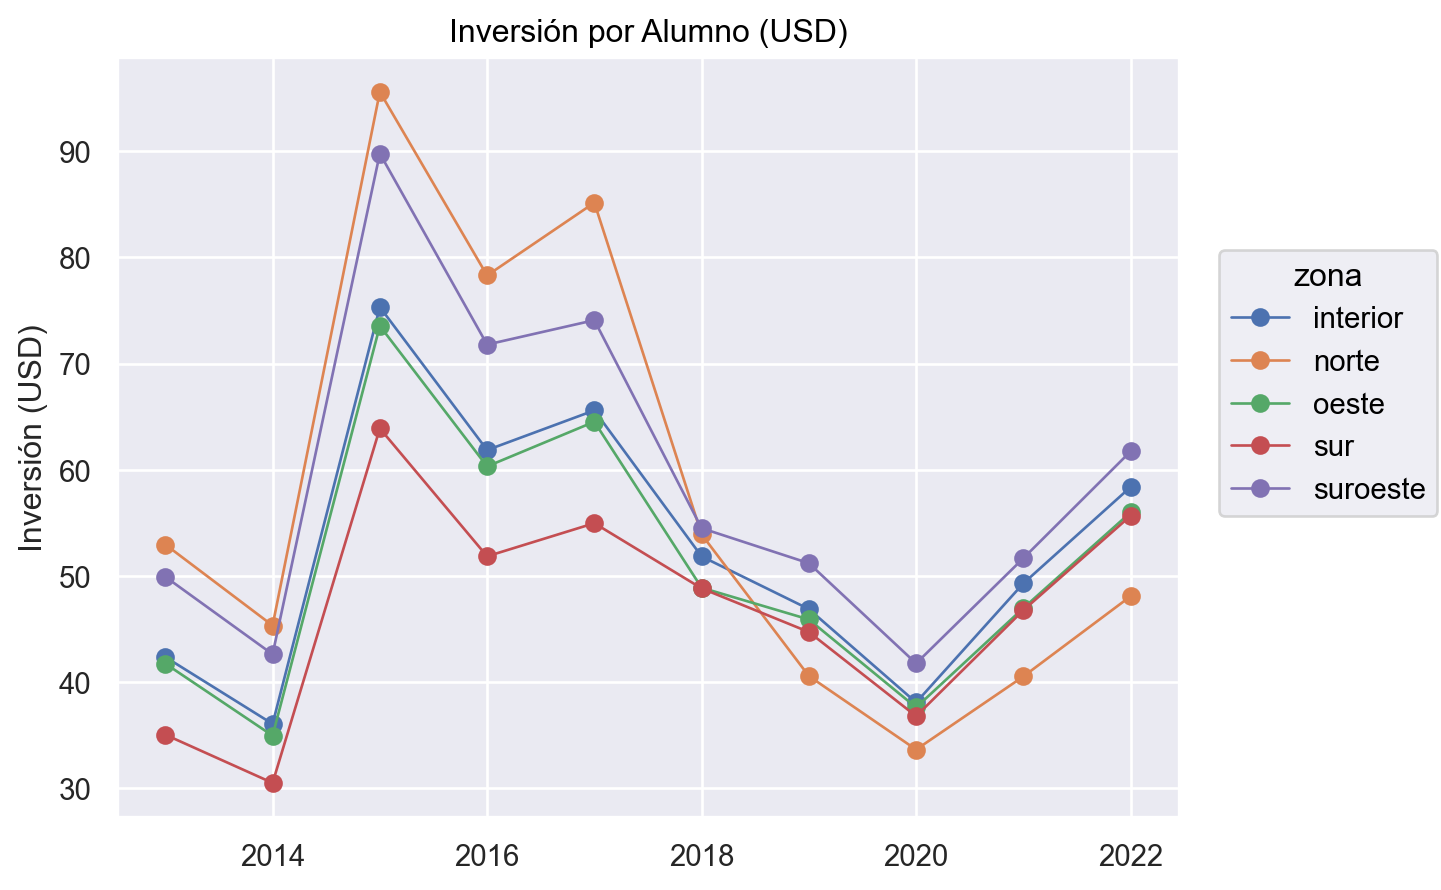

In [231]:
(so.Plot(df_poblacion_inversion,x="anio",y="inversion_alumno",color="zona")
    .add(so.Line(linewidth=1,marker="o"))
    .label(title="Inversión por Alumno (USD)",y="Inversión (USD)",x=None))

# Modelo de Prediccion - Regresión Lineal
---

Se arma el dataset en donde se va a basar la investigacion en los años brindados por dicha tabla, menos en 2020 por la pandemia.
 
Para la creación se necesita unir tablas y crear columnas nuevas, donde el fin de estas columnas es explicar la repitencia.


In [232]:
df_investigacion=df_repitencia.copy()

df_investigacion["inversion"]=df_poblacion_inversion["inversion_alumno"]
df_investigacion["saturacion_primaria"]=df_alumnos_colegio["matricula_nivel_primario"]/df_alumnos_colegio["unidades_de_servicio_nivel_primario"]
df_investigacion["saturacion_secundaria"]=df_alumnos_colegio["matricula_nivel_secundario"]/df_alumnos_colegio["unidades_de_servicio_nivel_secundario"]

df_investigacion["institucion_publicas_por_alumno"]=df_alumnos_colegio["matricula_total"]/df_alumnos_colegio["sector_de_gestion_estatal"]
df_investigacion["institucion_privadas_por_alumno"]=df_alumnos_colegio["matricula_total"]/df_alumnos_colegio["sector_de_gestion_privada"]

df_investigacion=pd.merge(df_investigacion,df_alumnos_colegio,how="inner",on=["anio","zona"])
df_investigacion=df_investigacion[df_investigacion["anio"]!=2020]
df_investigacion.head()

,anio,zona,promocion_efectiva_primaria,promocion_efectiva_secundaria,repitencia_primaria,repitencia_secundaria,reinscripcion_primaria,reinscripcion_secundaria,abandono_interanual_primaria,abandono_interanual_secundaria,...,unidades_de_servicio_nivel_primario,unidades_de_servicio_nivel_secundario,sector_de_gestion_estatal,sector_de_gestion_privada,matricula_nivel_inicial,matricula_nivel_primario,matricula_nivel_secundario,matricula_sexo_masculino,matricula_sexo_femenino,matricula_total
0,2013,interior,98.28,80.22,1.63,10.63,0.18,1.79,-0.09,7.36,...,866,747,2356,1117,130339,316391,226264,430394,446912,672994
1,2013,norte,98.02,84.14,1.28,8.41,0.10,1.51,0.60,5.94,...,595,589,1271,1178,99429,218510,179965,296709,304661,497904
2,2013,oeste,97.79,82.43,1.58,10.21,0.15,1.80,0.48,5.56,...,431,436,1116,675,72559,187415,142718,242813,254588,402692
3,2013,sur,97.51,79.92,1.74,10.97,0.13,1.71,0.62,7.40,...,961,997,2576,1486,166198,421984,331583,558089,569857,919765
4,2013,suroeste,97.53,81.91,1.59,9.17,0.10,1.44,0.78,7.47,...,327,332,842,444,51402,156664,126988,196101,200739,335054


La columna "Regimen Estricto" hace referencia al cambio hecho por el ministerio de educación  a nivel primario , en donde cambia el metodo de evaluación a los alumnos y alumnas, este cambio esta activo desde el año 2016 en donde influye mucho en el comportamiento del nivel educativo a nivel primario en el Área metropolitana.

In [233]:
df_investigacion["regimen_estricto"]=(df_investigacion["anio"]>=2016) & (df_investigacion["anio"]<=2022)

En este apartado se crea una nueva tabla en donde se va a bazar este modelo. La tabla va a estar separada por zona en donde cada zona tiene un comportamiento distinto ante cada variable. En este caso se usa la *ZONA SUR*

In [234]:
df_analisis=df_investigacion.copy()

df_analisis=df_analisis[df_analisis["zona"]=="sur"]
df_analisis=df_analisis.drop(columns=["zona"])

df_analisis

,anio,promocion_efectiva_primaria,promocion_efectiva_secundaria,repitencia_primaria,repitencia_secundaria,reinscripcion_primaria,reinscripcion_secundaria,abandono_interanual_primaria,abandono_interanual_secundaria,alumnos_promovidos_primaria,...,unidades_de_servicio_nivel_secundario,sector_de_gestion_estatal,sector_de_gestion_privada,matricula_nivel_inicial,matricula_nivel_primario,matricula_nivel_secundario,matricula_sexo_masculino,matricula_sexo_femenino,matricula_total,regimen_estricto
3,2013,97.51,79.92,1.74,10.97,0.13,1.71,0.62,7.40,98.28,...,997,2576,1486,166198,421984,331583,558089,569857,919765,False
8,2014,97.57,82.23,1.75,9.70,0.10,1.26,0.58,6.80,98.33,...,978,2562,1495,168370,423592,331910,561249,573202,923872,False
13,2015,97.52,82.48,1.96,10.26,0.08,1.44,0.44,5.81,98.19,...,956,2555,1487,169740,426811,334081,567898,580114,930632,False
18,2016,95.68,80.94,3.49,11.56,0.14,1.89,0.70,5.60,97.26,...,956,2581,1477,171044,430256,339148,575033,585159,940448,True
23,2017,95.38,82.22,3.64,11.37,0.12,1.38,0.86,5.03,97.31,...,944,2485,1487,174268,432457,344317,584582,598683,951042,True
28,2018,95.53,84.24,3.53,10.97,0.12,1.14,0.82,3.65,97.63,...,938,2467,1477,177034,434126,347958,588290,606004,959118,True
33,2019,96.26,85.83,3.17,9.67,0.12,1.00,0.45,3.51,97.84,...,932,2480,1463,176351,437980,353554,597608,617540,967885,True
43,2021,96.45,91.43,2.70,5.28,0.11,0.24,0.73,3.05,98.06,...,924,2397,1446,156174,441000,372088,592196,613927,969262,True
48,2022,96.74,89.67,2.84,6.34,0.13,0.61,0.30,3.38,97.55,...,923,2431,1449,158658,435834,370391,596444,612338,964883,True


En este apartado se arma una lista en donde dentro de dicha lista van a estar las variables mas relevantes (teniendo en cuenta el analisis exploratorio), estas variables seran utilizadas para ver la correlación con la variable a explicar *Repitencia Primaria*.

In [235]:
factores_importantes_repitencia_primaria=["repitencia_primaria","reinscripcion_primaria","inversion","saturacion_primaria","institucion_publicas_por_alumno","institucion_privadas_por_alumno","regimen_estricto","unidades_de_servicio_nivel_primario","sector_de_gestion_privada","sector_de_gestion_estatal",
                                          "matricula_nivel_primario","matricula_sexo_masculino","matricula_sexo_femenino"]

matriz_corr=df_analisis.corr()
analisis_repitencia=matriz_corr["repitencia_primaria"].reset_index()
analisis_repitencia=analisis_repitencia[analisis_repitencia["index"].isin(factores_importantes_repitencia_primaria)].reset_index(drop=True)
analisis_repitencia

,index,repitencia_primaria
0,repitencia_primaria,1.000000
1,reinscripcion_primaria,0.519738
2,inversion,0.422197
3,saturacion_primaria,0.667007
4,institucion_publicas_por_alumno,0.530469
5,institucion_privadas_por_alumno,0.554634
6,unidades_de_servicio_nivel_primario,0.503800
7,sector_de_gestion_estatal,-0.411557
8,sector_de_gestion_privada,-0.301276
9,matricula_nivel_primario,0.645294


Verifico si esas relaciones son coherentes o son relaciones en donde, el coeficiente es alto y hay una gran cantidad de outliers

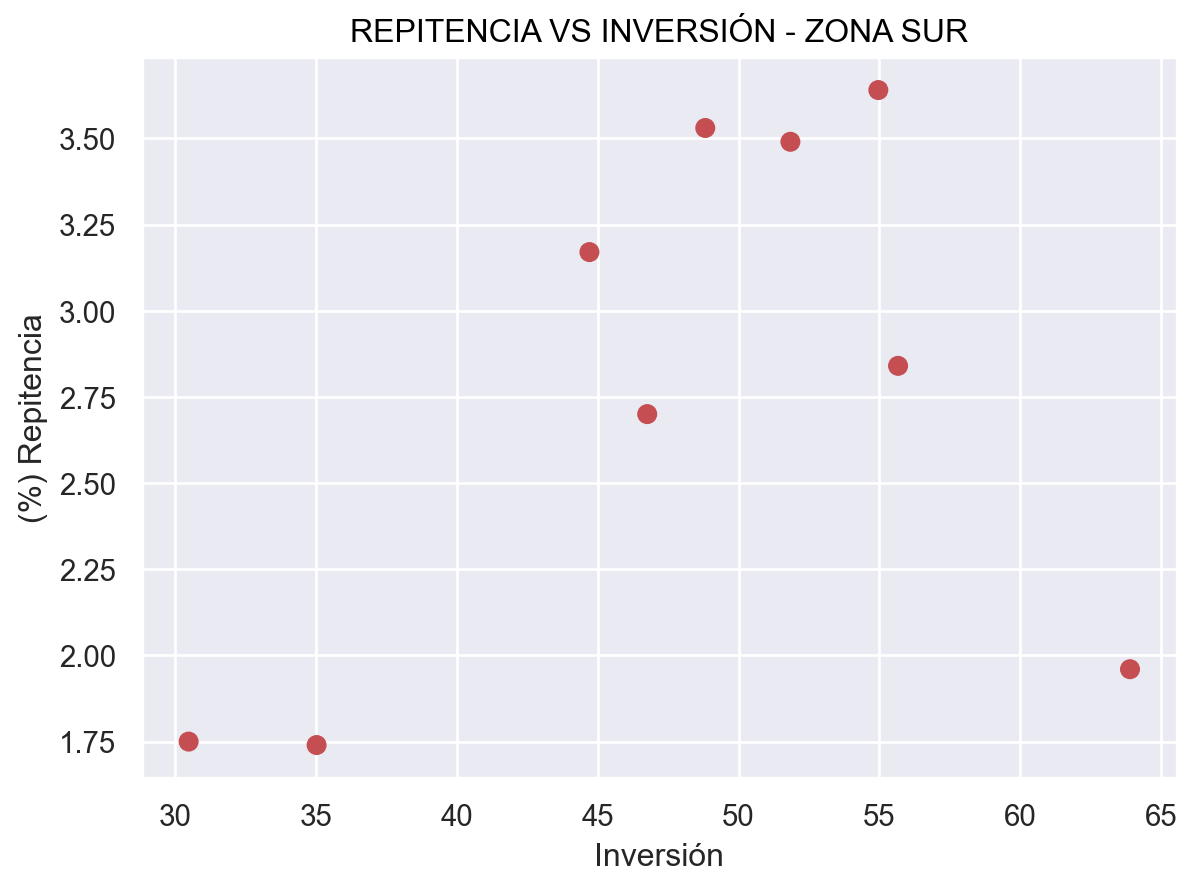

In [236]:
(so.Plot(df_analisis,x="inversion",y="repitencia_primaria") 
    .add(so.Dot(pointsize=7,color="r"))
    .label(title="REPITENCIA VS INVERSIÓN - ZONA SUR",x="Inversión",y="(%) Repitencia"))

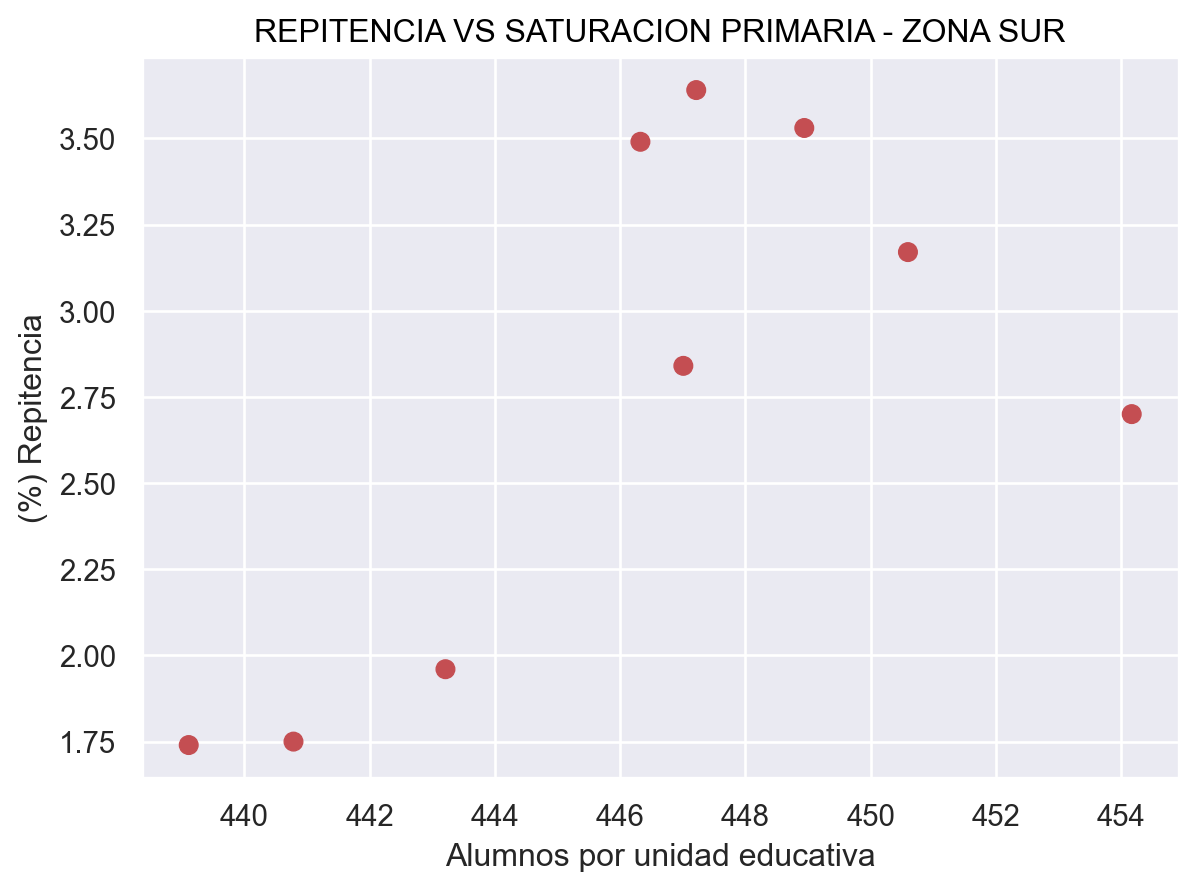

In [237]:
(so.Plot(df_analisis,x="saturacion_primaria",y="repitencia_primaria") 
    .add(so.Dot(pointsize=7,color="r"))
    .label(title="REPITENCIA VS SATURACION PRIMARIA - ZONA SUR",x="Alumnos por unidad educativa",y="(%) Repitencia"))

Este caso no se tiene en cuenta ya que se nota la presencia de 2 outliers.

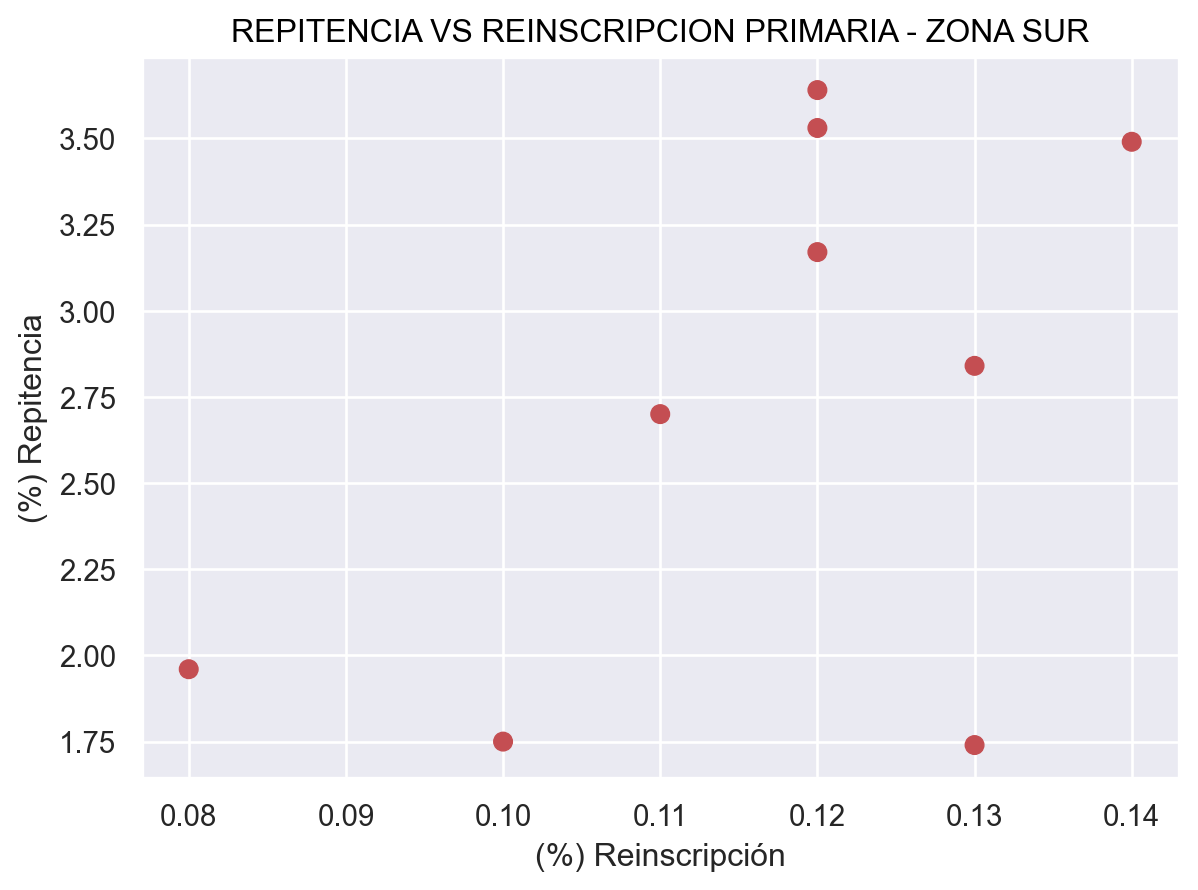

In [238]:
(so.Plot(df_analisis,x="reinscripcion_primaria",y="repitencia_primaria") 
    .add(so.Dot(pointsize=7,color="r"))
    .label(title="REPITENCIA VS REINSCRIPCION PRIMARIA - ZONA SUR",x="(%) Reinscripción",y="(%) Repitencia"))

Este valor está relacionado con la repitencia pero no se usa ya que está el valor *SATURACION PRIMARIA*, en donde se arrastra la relacion graficada y a su vez tiene en cuenta la cantidad de establecimientos educativos

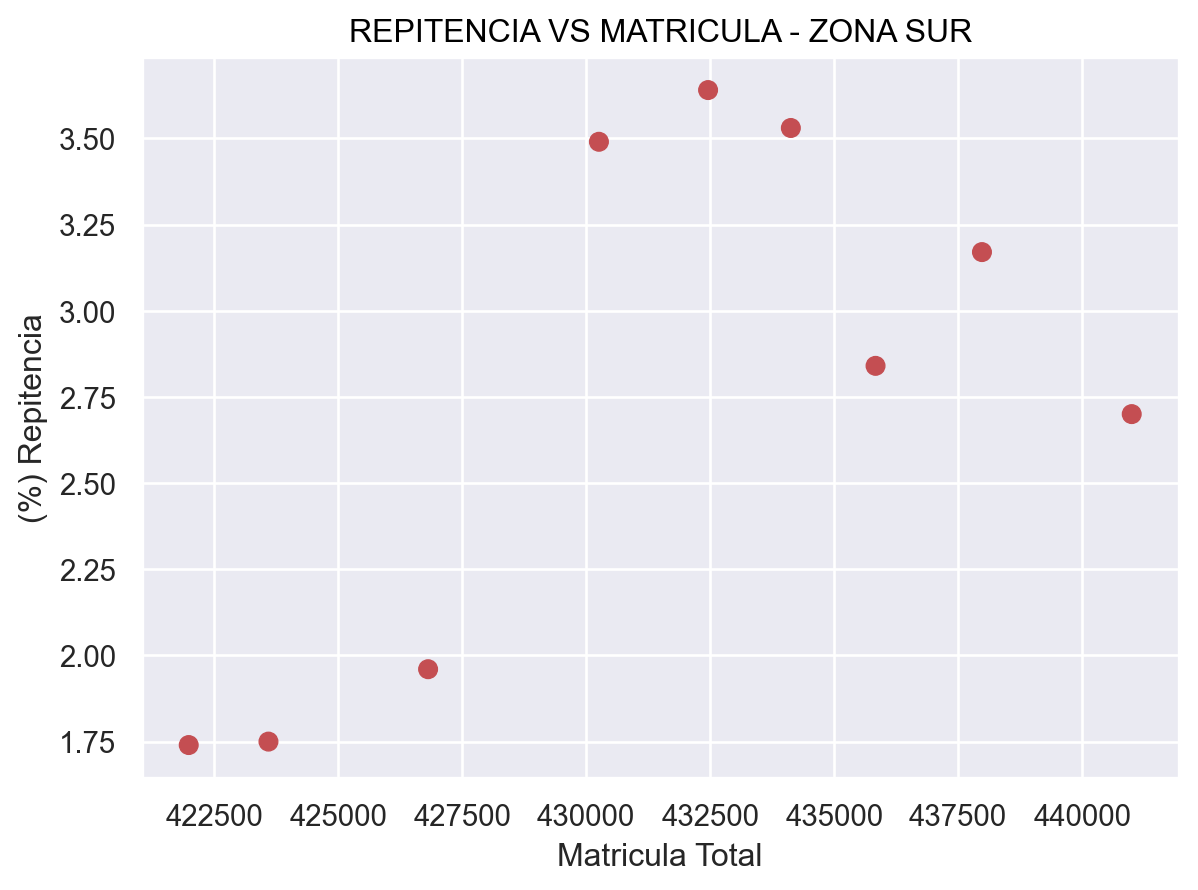

In [239]:
(so.Plot(df_analisis,x="matricula_nivel_primario",y="repitencia_primaria") 
    .add(so.Dot(pointsize=7,color="r"))
    .label(title="REPITENCIA VS MATRICULA - ZONA SUR",x="Matricula Total",y="(%) Repitencia"))

***MODELO DE REGRESIÓN LINEAL***
--

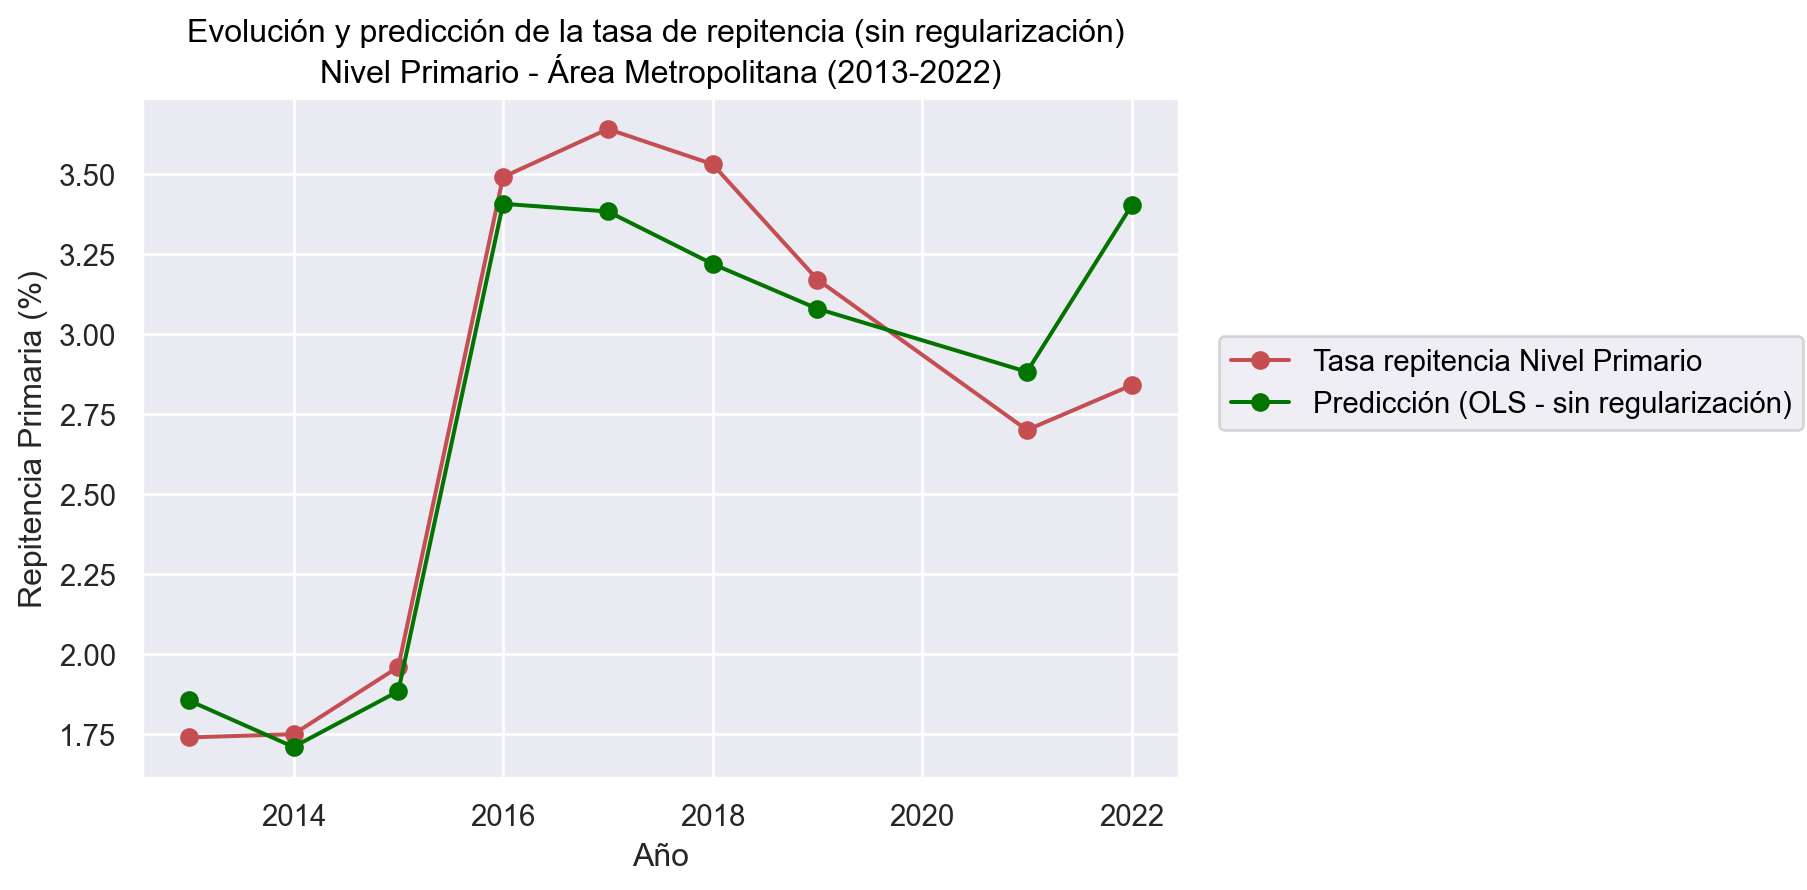

In [240]:
y,X=Formula('repitencia_primaria ~ saturacion_primaria + inversion + regimen_estricto ').get_model_matrix(df_analisis)
modelo=linear_model.LinearRegression(fit_intercept=False)
modelo.fit(X,y)

pred_repitencia=modelo.predict(X)
df_analisis["pred_repitencia"]=pred_repitencia

(so.Plot(df_analisis,x="anio")
    .add(so.Line(color="r",marker="o"),y="repitencia_primaria",label="Tasa repitencia Nivel Primario")
    .add(so.Line(color="#047400",marker="o"),y="pred_repitencia",label="Predicción (OLS - sin regularización)")
    .label(title="Evolución y predicción de la tasa de repitencia (sin regularización) \nNivel Primario - Área Metropolitana (2013-2022)",x="Año",y="Repitencia Primaria (%)"))

En este Apartado se muestra como se importó la tabla de prediccion, tabla que fue utilizada en el dashboard de POWER BI
----

In [241]:
prediccion=df_analisis[["anio","repitencia_primaria","pred_repitencia"]].copy()
prediccion["zona"]="sur"
prediccion["pred_repitencia"]=prediccion["pred_repitencia"].round(2)
prediccion

,anio,repitencia_primaria,pred_repitencia,zona
3,2013,1.74,1.86,sur
8,2014,1.75,1.71,sur
13,2015,1.96,1.88,sur
18,2016,3.49,3.41,sur
23,2017,3.64,3.38,sur
28,2018,3.53,3.22,sur
33,2019,3.17,3.08,sur
43,2021,2.70,2.88,sur
48,2022,2.84,3.40,sur


In [242]:
prediccion.to_csv(r"G:\Mi unidad\Proyecto Repitencia\prediccion.csv", index=False,encoding="utf-8")